# K-Means Clustering

## Table of Contents
1. [Introduction](#1-introduction)
2. [Theory & Mathematics](#2-theory--mathematics)
3. [Assumptions & Requirements](#3-assumptions--requirements)
4. [When to Use This Algorithm](#4-when-to-use-this-algorithm)
5. [Implementation from Scratch (NumPy)](#5-implementation-from-scratch-numpy)
6. [Implementation with Scikit-learn](#6-implementation-with-scikit-learn)
7. [Hyperparameter Tuning](#7-hyperparameter-tuning)
8. [Complete Hyperparameter Reference](#8-complete-hyperparameter-reference)
9. [Practical Tips & Common Pitfalls](#9-practical-tips--common-pitfalls)
10. [Real-world Examples](#10-real-world-examples)
11. [Comparison with Other Algorithms](#11-comparison-with-other-algorithms)
12. [References](#12-references)

---

## 1. Introduction

### What is K-Means?

K-Means is the classic **partitioning** clustering algorithm: it splits n samples into k groups so that every point belongs to the cluster with the **nearest centroid**. Unlike everything in notebooks 01–11, there is **no target variable** here — this is **unsupervised learning**: the algorithm discovers structure in the features alone, and its output is a *partition*, not predictions against ground truth.

**Key characteristics:**
- **Unsupervised learning** — learns from feature data alone
- **Partitioning method** — every point receives exactly one hard cluster label
- **Centroid-based** — a cluster *is* its mean vector ($\mu$)
- **Distance-based** — uses squared Euclidean distance exclusively
- **Iterative refinement** — alternates two cheap steps until stable

**Historical Context:**
- The term "k-means" was coined by James MacQueen in 1967
- The algorithm we all use was published by Stuart Lloyd in 1982 (Bell Labs, developed 1957 for pulse-code modulation)
- **k-means++** seeding by Arthur & Vassilvitskii (2007) fixed its biggest weakness — bad initialization
- Still one of the most widely used clustering algorithms in industry today

**Main Use Cases:**
- **Customer segmentation**: personas for marketing (Example 1 below)
- **Color quantization / image compression**: reduce an image to a k-color palette (Example 2 below)
- **Anomaly detection**: points far from every centroid are outliers
- **Feature engineering**: cluster id or distance-to-centroid as extra features
- **Data exploration**: the first thing to run on unlabeled data

**How it works (simplified):**
1. Choose k — how many clusters you believe exist
2. Pick k starting centroids (the *initialization* — details matter a lot!)
3. **Assign**: give every point to its nearest centroid
4. **Update**: move each centroid to the mean of its assigned points
5. Repeat 3–4 until assignments stop changing
6. Return labels + centroids

**What is different about this notebook:**
- Section 7 "tunes" k with **internal metrics** (elbow, silhouette) — there is no accuracy and no GridSearchCV against y
- Sections 5/6 fit on **blobs** and intentionally *fail* on **rings** — and there is **no train/test split at all**: clustering has no labels to hold out, so models are judged on the very data they fit
- Section 11 compares algorithms by partition **quality**, not correctness

In [1]:
# Import necessary libraries
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.datasets import load_sample_image, make_blobs, make_circles, make_moons
from sklearn.decomposition import PCA
from sklearn.metrics import (
    adjusted_rand_score,
    silhouette_samples,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

sys.path.append('../src')
from models.clustering_models import KMeansScratch

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully!")
print(f"NumPy version: {np.__version__}")
print(f"Pandas version: {pd.__version__}")
print("KMeansScratch imported from src/models/clustering_models.py")

Libraries imported successfully!
NumPy version: 2.5.1
Pandas version: 3.0.3
KMeansScratch imported from src/models/clustering_models.py


---

## 2. Theory & Mathematics

### Core Concept: Minimizing Inertia

K-Means optimizes a single quantity: **inertia** (also called WCSS — Within-Cluster Sum of Squares):

$$\min_{C} \; \sum_{i=1}^{n} \|x_i - \mu_{c_i}\|^2$$

$$\mu_j = \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i$$

where:
- $C$ = the partition (which cluster every point belongs to)
- $c_i$ = the cluster index assigned to point $x_i$
- $C_j$ = the set of points currently assigned to cluster $j$
- $\mu_j$ = the centroid (mean vector) of cluster $j$
- $\|x_i - \mu_{c_i}\|^2$ = squared Euclidean distance from each point to its own centroid

**Intuition**: every point should be as close as possible to the "center" of its group. Low inertia = compact, blob-like clusters.

### The Algorithm: Lloyd's Iteration

**K-Means is coordinate descent on the inertia objective.** It alternates two steps, and each step provably decreases (or preserves) inertia:

**Step 1 — Assignment step** (assign points to nearest centroid):

$$c_i = \arg\min_j \; \|x_i - \mu_j\|^2 \quad \text{for every point } i$$

**Step 2 — Update step** (move each centroid to its cluster mean):

$$\mu_j \leftarrow \frac{1}{|C_j|} \sum_{x_i \in C_j} x_i$$

**Why it is guaranteed to converge:**
1. The assignment step can only lower inertia — every point is moved to the centroid that is *closest to it*, which is the best choice for the current centroids
2. The update step minimizes inertia *exactly* for a fixed assignment — the arithmetic mean minimizes the sum of squared deviations within a group
3. There are only finitely many partitions of n points into k groups
4. A non-increasing sequence on a finite set must stabilize → Lloyd's reaches a **local minimum** (a fixed point: labels stable, centroids = their clusters' means)

**BUT: convergence ≠ optimality.** The global minimum of the inertia objective is **NP-hard to find exactly**. Lloyd's descends into *a* local minimum, and which one depends entirely on initialization:

$$\text{K-Means output} = f(\text{initialization})$$

Two different random seeds on the same data can yield noticeably different partitions.

### The Initialization Problem & k-means++

The first centroid placement decides the basin of attraction. Bad seeding → poor local minimum → inflated inertia.

**Naive random init**: sample k distinct points uniformly as starting centroids. Failure mode demonstrated in §5: on lopsided data (one big, one blobby cluster), random seeding can put **two** centroids inside the dense region; one of the "two blobs" gets only a single point as its cluster — initial inertia is large and convergence is slow.

**k-means++ (Arthur & Vassilvitskii 2007)** — probabilistic seeding that spreads centers out:

1. Pick the first center $c_1$ uniformly at random from the data
2. For each subsequent center: compute $D^2(x) = \min_j \|x - c_j\|^2$ (squared distance to the **nearest already-chosen** center)
3. Sample the next center with probability proportional to $D^2(x)$:

$$P(x \text{ chosen as next center}) = \frac{D^2(x)}{\sum_{x'} D^2(x')}$$

4. Repeat until k centers are chosen

**Effect**: points far away from all chosen centers are far more likely to be picked next. Seeding stays random (stochastic — that's why `n_init` still matters) but *spreads*: expected inertia lands within a logarithmic factor of the optimal ($8(\ln k + 5)$-competitive), versus a potentially exponential badness for plain random seeding.

When all remaining $D^2$ mass is zero (several points already sit exactly on chosen centers), any fallback row is a valid center — the downstream empty-cluster repair (see §5) resolves exact duplicates.

### Empty Clusters

During Lloyd's iteration a centroid can end up with **zero** points assigned (it "loses" all its points to neighbors). Common responses:
- Ignore / error out (early versions)
- Reseed it on the point **farthest from its own centroid** — what our scratch implementation does (§5): the biggest source of inertia joins the game immediately
- sklearn: relocates the empty center to the point(s) contributing most to inertia (same spirit)

### Geometric View: Voronoi Partition

At a fixed point, the centroids define a **Voronoi partition** of the space: the region around each centroid contains exactly the points closest to it. K-Means finds a partition whose cell boundaries are the perpendicular bisectors between neighboring centroids — this is precisely why every cluster it can express is connected and convex (§5 rings demo shows the failure).

### Computational Complexity

Per Lloyd iteration (brute-force distances):
- **Assignment**: all n×k point–centroid distances — O(n·k·m) where m = features
- **Update**: recomputing k means — O(n·m)
- Total for i iterations: **O(n · k · m · i)**

- **Memory**: O(n·m + k·m) — the data plus k centroid coordinates

 sklearn accelerates the assignment step with the triangle inequality (the `algorithm='elkan'` machinery), with identical results; for truly large n see MiniBatchKMeans (§8).

### Variants (know they exist)

| Variant | Change | Why |
|---|---|---|
| k-means++ | smarter seeding | better local minima |
| MiniBatchKMeans | mini-batch updates | scales to millions of rows |
| k-medoids (PAM) | centroid = actual data point (medoid) | robust to outliers, works with arbitrary dissimilarities |
| ISODATA / x-means | vary k during the run | unknown cluster count |
| Kernel k-means | kernel-induced distance | non-convex cluster shapes |
| k-means\|\| | parallel k-means++ | MapReduce-scale seeding |

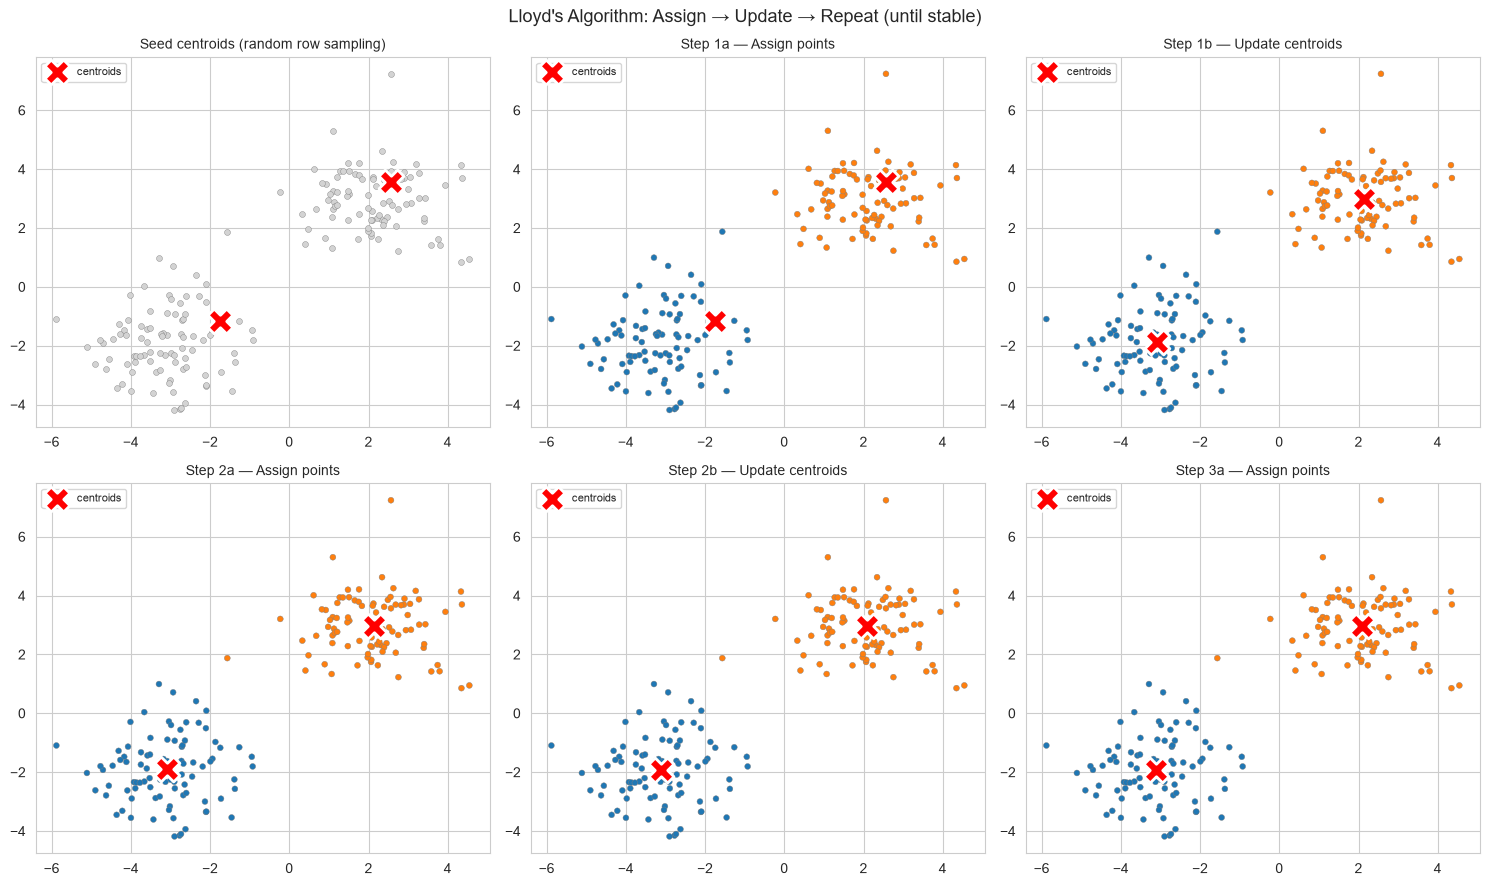

Total Lloyd steps executed: 3 (iterations to convergence)
Final cluster sizes: [90 90]

💡 Watch the two frames of each step:
   • 'a' frames color the points by nearest centroid (assignment step)
   • 'b' frames move the centroids to their cluster means (update step)
   • After ~2-3 steps the picture stops changing: it has converged!


In [2]:
# Visualize Lloyd's algorithm step by step
np.random.seed(42)

# A small 2-D dataset with obvious structure
X_lloyd, _ = make_blobs(n_samples=180, centers=[(-3, -2), (2, 3)], cluster_std=1.1, random_state=42)

# Hand-run Lloyd's algorithm while recording state — same math as KMeansScratch
k = 2
rng = np.random.RandomState(7)
centroids = X_lloyd[rng.choice(len(X_lloyd), size=k, replace=False)].copy()

history = [("Seed centroids (random row sampling)", centroids.copy(), None)]

for step in range(1, 6):
    sq_dist = ((X_lloyd[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    labels = sq_dist.argmin(axis=1)
    history.append((f"Step {step}a — Assign points", centroids.copy(), labels.copy()))

    new_centroids = np.array([X_lloyd[labels == j].mean(axis=0) for j in range(k)])
    shift = np.sqrt(((new_centroids - centroids) ** 2).sum())
    history.append((f"Step {step}b — Update centroids", new_centroids.copy(), labels.copy()))
    centroids = new_centroids
    if shift < 1e-4:
        break

# Plot the first five frames
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
colors = np.array(["#1f77b4", "#ff7f0e"])

for ax, (title, cents, labs) in zip(axes.flat, history[:6]):
    if labs is None:
        ax.scatter(X_lloyd[:, 0], X_lloyd[:, 1], s=18, c="lightgray", edgecolors="gray", linewidths=0.3)
    else:
        ax.scatter(X_lloyd[:, 0], X_lloyd[:, 1], s=18, c=colors[labs], edgecolors="gray", linewidths=0.3)
    ax.scatter(cents[:, 0], cents[:, 1], marker="X", s=320, c="red", edgecolors="white", linewidths=2, zorder=5, label="centroids")
    ax.set_title(title, fontsize=10)
    ax.legend(loc="upper left", fontsize=8)

# Hide any panel not covered by the recorded history
for ax in axes.flat[min(len(history), 6):]:
    ax.axis("off")

plt.suptitle("Lloyd's Algorithm: Assign → Update → Repeat (until stable)", fontsize=13)
plt.tight_layout()
plt.show()

n_steps = (len(history) - 1) // 2
print(f"Total Lloyd steps executed: {n_steps} (iterations to convergence)")
final_labels = history[-1][2]
print(f"Final cluster sizes: {np.bincount(final_labels, minlength=k)}")
print("\n💡 Watch the two frames of each step:")
print("   • 'a' frames color the points by nearest centroid (assignment step)")
print("   • 'b' frames move the centroids to their cluster means (update step)")
print("   • After ~2-3 steps the picture stops changing: it has converged!")

---

## 3. Assumptions & Requirements

### The Assumptions K-Means Makes (and quietly breaks when violated!)

K-Means is a geometric algorithm — it implicitly assumes the shapes it is fitting actually exist in your data:

1. **Convex, blob-shaped clusters**
   - The Voronoi partition geometry (§2) means every cluster K-Means can express is connected and convex
   - Concentric rings, crescents, interleaved half-moons? It slices them **by sector**, not by shape
   - (Demo in §5; alternatives in §11)

2. **Clusters of similar size (inertia or point counts)**
   - The objective counts *total* squared distance — a big cluster and a tiny one are treated identically
   - One blob with 2000 points + one with 100: K-Means happily splits the big blob in half to win more inertia

3. **Clusters of similar density**
   - Spheres of different spreads (σ=0.5 vs σ=3.0): the loose cluster gets fragmented or swallowed

4. **Spherical (isotropic) clusters in Euclidean space**
   - Distance is plain Euclidean — long diagonal ellipses are described worse than round blobs
   - whiten / rotate with PCA first if your clusters are elongated; or use GMM (full covariance) instead

5. **Euclidean geometry is meaningful**
   - **Feature scale matters directly** — a feature ranging 0–10000 dominates the distance. Standardize first (§4 demo)!
   - Categorical features need one-hot plus a distance decision; plain Euclidean on sparse one-hot is rarely what you want

6. **k is known or knowable**
   - The algorithm never *discovers* the number of clusters — you impose it (elbow / silhouette in §7)

7. **Outliers are absent (or rare)**
   - Every point must join exactly one cluster — an outlier either drags its centroid or becomes a "cluster of one"
   - DBSCAN is the outlier-tolerant alternative (§11)

8. **Independence of observations**
   - Time series / spatial data with autocorrelation: cluster structure can reflect sampling patterns, not real groups

### What K-Means Does NOT Require

✅ **No target variable** — that's the point (unsupervised)
✅ **No distribution assumptions** — no Gaussianity of individual features, no linear relationships
✅ **No feature independence** — correlated features are fine (although they effectively double-weight the shared direction)
✅ **No feature types constraints beyond numeric** — one-hot works (with care)

### What K-Means DOES Require in Practice

| Requirement | Why | Fix if violated |
|---|---|---|
| **Numeric features** | Euclidean distance only | encode / embed categoricals first |
| **Feature scaling** | distance is scale-sensitive | `StandardScaler` / `MinMaxScaler` (§4 demo) |
| **No (or few) missing values** | cannot compute distance with NaN | impute first; drop sparse rows |
| **Bounded k vs n** | k ≤ n points, obviously; k too big = "clusters" of single points | elbow / silhouette |
| **Outlier handling** | outliers corrupt centroids | detect & drop, cap tails, or use DBSCAN |
| **Metric → purpose alignment** | "feature-close" must mean "business-similar" | select features deliberately; weight/whiten |

### Key Differences from Supervised Algorithms (notebooks 01–11)

| Aspect | K-Means | Supervised models (01–11) |
|---|---|---|
| **Learning signal** | structure in X only | labeled pairs (X, y) |
| **Output** | partition + centroids | predictions for new rows |
| **Score against truth** | not available (no y) | accuracy / R² / etc. |
| **Split train/test** | not typically — fit on everything *you trust* | mandatory to detect overfitting |
| **"Overfitting" analogue** | wrong k; artifacts of local minima | memorizing training labels |
| **Evaluation** | internal metrics (inertia, silhouette, DB) — external only with an *independent* proxy label | metrics vs held-out y |
| **Prediction for new rows** | possible (assign to nearest centroid; scratch & sklearn support `predict`) | native |

---

## 4. When to Use This Algorithm

### ✅ Use K-Means When:

1. **You expect blob-like groups**
   - Customer segments, document topics (on embeddings), image palette extraction
   - Roughly convex/spherical clusters with similar sizes — exactly what the objective encodes

2. **You need FAST, scalable clustering**
   - O(n·k·m) per iteration — linear in samples
   - Scales to millions of rows (MiniBatchKMeans variant)
   - Every algorithm in §11 is slower or stricter about geometry

3. **k is known, or knowable via elbow/silhouette**
   - Number of products, brands, marketing personas is often roughly known
   - Or the dataset's inertia curve shows an obvious bend (§7)

4. **You need a way to assign NEW rows later**
   - Cluster id as a categorical feature in a supervised pipeline
   - `predict()` = nearest fitted centroid, O(k·m) — instant

5. **Interpretability of "a center of mass" matters**
   - "Cluster A averages 34 years old, $52k income, 3.2 purchases" — a directly explainable prototype
   - Hierarchical clustering gives this too, but K-Means is cheaper

6. **Quick baseline / first look**
   - Requires nothing but numeric features + a k guess
   - An honest first read of structure before investing in model selection

7. **Vector quantization / compression**
   - Color palettes (§10, Example 2), codebook for features, retrieval index building

### ❌ Avoid K-Means When:

1. **Clusters are non-convex or density varies**
   - Rings, moons, intertwined spirals, density-varying clusters (§5 failure demos)
   - Use DBSCAN, Spectral, or agglomerative with the right linkage (§11)

2. **The number of clusters is unknown AND hard to determine**
   - Elbow/silhouette hints are reliable only on fairly clean data
   - Gaussian Mixture Models with BIC model selection are a principled alternative

3. **You need probabilistic/fuzzy membership**
   - A point "between two clusters" gets one hard label
   - GMM gives soft membership probabilities

4. **Outliers must not distort the model**
   - One point far from everything either joins some cluster or forms its own
   - DBSCAN explicitly labels outliers as noise (-1)

5. **Categorical variables dominate**
   - One-hot + Euclidean produces lopsided distance skews; k-modes / mixed-type methods fit better

6. **Data is high-dimensional with many irrelevant features**
   - Irrelevant dimensions add noise to Euclidean distance; ~100+ dims is a real warning sign
   - Reduce with PCA (notebook 15), select features, or use cosine distance via `normalize`

7. **Cluster sizes are extremely unequal**
   - One dominant big cluster + rare minorities: K-Means fragments the big one
   - Consider density-based methods

8. **Data is huge and n_init must be high**
   - n_init=25 restarts × O(n·k·m·i) adds up; MiniBatchKMeans or a k-means||-style seed helps

### Clustering vs Classification (a permanent distinction)

| Task | Type | "Answer available?" | Example |
|---|---|---|---|
| Classification (nb 02,03,05,06,07) | supervised | yes — labels | spam vs not-spam |
| Regression (nb 01,04) | supervised | yes — continuous y | price forecasting |
| **Clustering (this nb, 13, 14)** | **unsupervised** | **no — structure inferred** | **group customers by behavior** |
| Dimensionality reduction (nb 15) | unsupervised | no | visualize 64→2 dims |

### K-Means vs the Other Clustering Algorithms (full comparison in §11)

**vs Hierarchical (nb 13):**
- K-Means: needs k upfront, O(n) — must specify k; fast; produces only one partition
- Hierarchical: no k needed up-front (cut the dendrogram later); O(n²) memory; gives a full hierarchy

**vs DBSCAN (nb 14):**
- K-Means: every point labeled; fails on non-convex shapes; k required
- DBSCAN: discovers k itself; handles noise/outliers; struggles with varying density; no `predict` for new rows

**vs GMM:**
- K-Means: hard assignments, spherical clusters (equal variance implicitly)
- GMM: soft probabilities, ellipsoidal clusters (per-cluster covariance), usually slower, needs scaling too

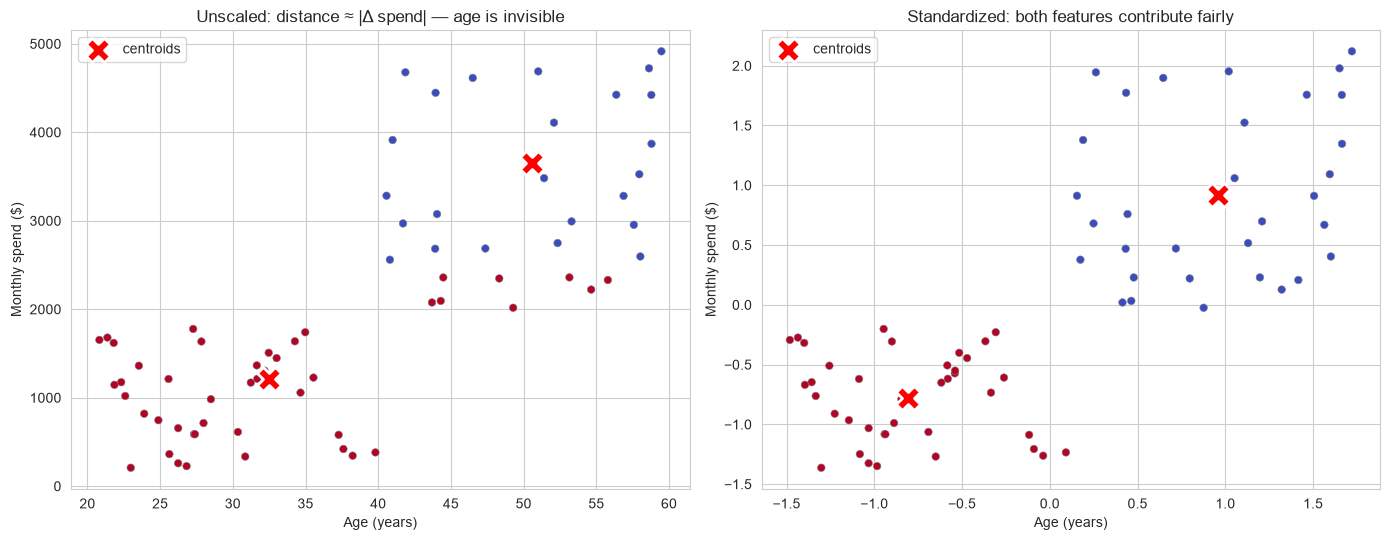

Feature ranges (unscaled):  age 21-59  |  spend $208-$4915
Feature std devs:           age σ=12.1  |  spend σ=$1351
Spend variance / age variance = 12532x

💡 In the unscaled plot, distance is measured almost entirely in dollars:
   • horizontal separation (age) is ~40 units; vertical (spend) is ~thousands
   • the 2-cluster solution nearly ignores the age dimension entirely
   • after StandardScaler both features have σ=1 — the grouping now reflects both


In [3]:
# WHY scaling matters: distance is dominated by the widest-ranged feature
np.random.seed(42)

# 70 customers: age (20-60) and spending ($/month) that grows with age
age = np.random.uniform(20, 60, 70)
group = (age > 40).astype(int)
spend = np.where(group == 1, np.random.uniform(2000, 5000, 70), np.random.uniform(200, 1800, 70))

X_unscaled = np.column_stack([age, spend])
X_scaled_demo = StandardScaler().fit_transform(X_unscaled)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

for ax, X_in, title in [
    (axes[0], X_unscaled, "Unscaled: distance ≈ |Δ spend| — age is invisible"),
    (axes[1], X_scaled_demo, "Standardized: both features contribute fairly"),
]:
    km = KMeansScratch(n_clusters=2, n_init=5, random_state=0).fit(X_in)
    ax.scatter(X_in[:, 0], X_in[:, 1], c=km.labels_, cmap="coolwarm", s=30, edgecolors="gray", linewidths=0.4)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], marker="X", s=300, c="red", edgecolors="white", linewidths=2, label="centroids", zorder=5)
    ax.set_xlabel("Age (years)")
    ax.set_ylabel("Monthly spend ($)")
    ax.set_title(title)
    ax.legend()

plt.tight_layout()
plt.show()

print(f"Feature ranges (unscaled):  age {age.min():.0f}-{age.max():.0f}  |  spend ${spend.min():.0f}-${spend.max():.0f}")
print(f"Feature std devs:           age σ={age.std():.1f}  |  spend σ=${spend.std():.0f}")
print(f"Spend variance / age variance = {spend.var() / age.var():.0f}x")
print("\n💡 In the unscaled plot, distance is measured almost entirely in dollars:")
print("   • horizontal separation (age) is ~40 units; vertical (spend) is ~thousands")
print("   • the 2-cluster solution nearly ignores the age dimension entirely")
print("   • after StandardScaler both features have σ=1 — the grouping now reflects both")

---

## 5. Implementation from Scratch (NumPy)

Let's implement K-Means from scratch to understand exactly what Lloyd's algorithm does — starting points, the two alternating steps, restarts, and the empty-cluster edge case.

In [4]:
# Import our from-scratch implementation
import sys
sys.path.append('../src')

from models.clustering_models import KMeansScratch

print("✅ Imported custom K-Means implementation!")
print("\nAvailable class: KMeansScratch")
print("  • KMeansScratch(n_clusters, init, n_init, max_iter, tol, random_state)")
print("  • .fit(X) → runs n_init full restarts, keeps the lowest-inertia one")
print("  • .predict(X) → nearest fitted centroid (new-row inference!)")
print("  • .fit_predict(X) → fit + return training labels")
print("\nFitted attributes (same names as sklearn, by design):")
print("  • cluster_centers_  (n_clusters, n_features)")
print("  • labels_           (n_samples,)")
print("  • inertia_          float — sum of squared distances to own centroid")
print("  • n_iter_           int — iterations executed by the best run")

✅ Imported custom K-Means implementation!

Available class: KMeansScratch
  • KMeansScratch(n_clusters, init, n_init, max_iter, tol, random_state)
  • .fit(X) → runs n_init full restarts, keeps the lowest-inertia one
  • .predict(X) → nearest fitted centroid (new-row inference!)
  • .fit_predict(X) → fit + return training labels

Fitted attributes (same names as sklearn, by design):
  • cluster_centers_  (n_clusters, n_features)
  • labels_           (n_samples,)
  • inertia_          float — sum of squared distances to own centroid
  • n_iter_           int — iterations executed by the best run


K-MEANS (FROM SCRATCH)

📊 Dataset:
  Samples: 450
  Features: 2
  True clusters (used ONLY for the external check below): 4

📈 Fit results:
  Inertia: 695.51
  Iterations executed by the best run: 2
  Cluster sizes: [113 112 113 112]
  Centroids (rows = clusters):
    μ_0 = (   -2.59,     9.07)
    μ_1 = (   -6.91,    -6.94)
    μ_2 = (    4.70,     1.96)
    μ_3 = (   -8.78,     7.46)

🔍 Quality:
  Adjusted Rand Index vs 'truth' (synthetic only!): 1.0000
  Silhouette (internal metric — uses only X & labels): 0.8140

🔮 Predict on 4 NEW, unseen points (no refit!):
    [0. 0.] → cluster 2
    [8. 8.] → cluster 2
    [-6. -6.] → cluster 1
    [ 4. -8.] → cluster 2


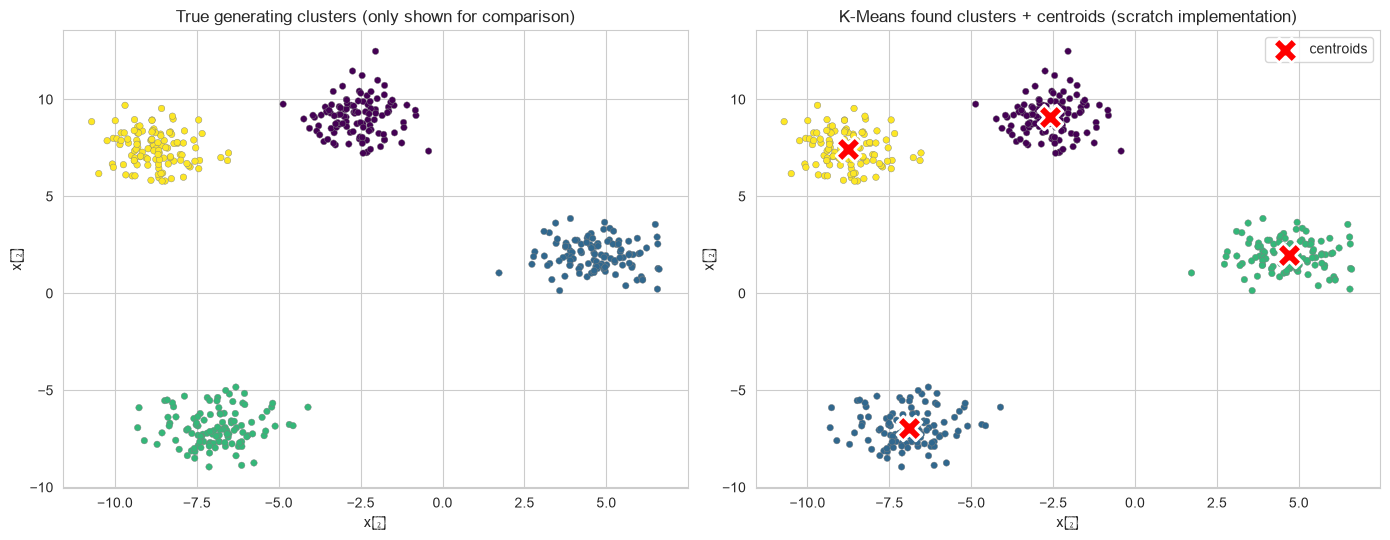

💡 Note the `predict` on new points: K-Means is not just a 'one-shot' algorithm.
   Once centroids are fitted, new data can be assigned in O(n_new · k · m).


In [5]:
# Generate a 2-D blobs dataset (structured, easy to visualize)
X_blobs, y_true_blobs = make_blobs(
    n_samples=450,
    centers=4,
    cluster_std=0.9,
    random_state=42,
)

print("=" * 60)
print("K-MEANS (FROM SCRATCH)")
print("=" * 60)
print(f"\n📊 Dataset:")
print(f"  Samples: {len(X_blobs)}")
print(f"  Features: {X_blobs.shape[1]}")
print(f"  True clusters (used ONLY for the external check below): {len(np.unique(y_true_blobs))}")

# Train model
kmeans_scratch = KMeansScratch(
    n_clusters=4,
    init="k-means++",
    n_init=10,
    max_iter=300,
    tol=1e-4,
    random_state=42,
)
kmeans_scratch.fit(X_blobs)

print("\n📈 Fit results:")
print(f"  Inertia: {kmeans_scratch.inertia_:.2f}")
print(f"  Iterations executed by the best run: {kmeans_scratch.n_iter_}")
print(f"  Cluster sizes: {np.bincount(kmeans_scratch.labels_)}")
print(f"  Centroids (rows = clusters):")
for i, c in enumerate(kmeans_scratch.cluster_centers_):
    print(f"    μ_{i} = ({c[0]:8.2f}, {c[1]:8.2f})")

# How well does the recovered partition match the true generating clustering?
# (External check for THIS synthetic-land demo. In practice — you have no y!)
ari_ext = adjusted_rand_score(y_true_blobs, kmeans_scratch.labels_)
sil_int = silhouette_score(X_blobs, kmeans_scratch.labels_)
print(f"\n🔍 Quality:")
print(f"  Adjusted Rand Index vs 'truth' (synthetic only!): {ari_ext:.4f}")
print(f"  Silhouette (internal metric — uses only X & labels): {sil_int:.4f}")

# New-row inference: assign an unseen point to its nearest centroid
new_points = np.array([
    [0.0, 0.0],
    [8.0, 8.0],
    [-6.0, -6.0],
    [4.0, -8.0],
])
new_labels = kmeans_scratch.predict(new_points)
print(f"\n🔮 Predict on {len(new_points)} NEW, unseen points (no refit!):")
for pt, lb in zip(new_points, new_labels):
    print(f"    {pt} → cluster {lb}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

axes[0].scatter(X_blobs[:, 0], X_blobs[:, 1], c=y_true_blobs, cmap="viridis", s=22, edgecolors="gray", linewidths=0.3)
axes[0].set_title("True generating clusters (only shown for comparison)")
axes[0].set_xlabel("x₀"); axes[0].set_ylabel("x₁")

axes[1].scatter(X_blobs[:, 0], X_blobs[:, 1], c=kmeans_scratch.labels_, cmap="viridis", s=22, edgecolors="gray", linewidths=0.3)
axes[1].scatter(kmeans_scratch.cluster_centers_[:, 0], kmeans_scratch.cluster_centers_[:, 1],
                marker="X", s=320, c="red", edgecolors="white", linewidths=2, label="centroids", zorder=5)
axes[1].set_title("K-Means found clusters + centroids (scratch implementation)")
axes[1].set_xlabel("x₀"); axes[1].set_ylabel("x₁")
axes[1].legend()

plt.tight_layout()
plt.show()

print("💡 Note the `predict` on new points: K-Means is not just a 'one-shot' algorithm.")
print("   Once centroids are fitted, new data can be assigned in O(n_new · k · m).")

### How the Scratch Version Works (a guided tour)

Read `src/models/clustering_models.py` alongside these five facts:

**1. One matrix identity does all the distance work — `_squared_distances`:**
$$\|a - b\|^2 = \|a\|^2 + \|b\|^2 - 2\,a\cdot b$$
so the full (n × k) matrix of squared distances is one matrix product `A @ B.T` plus two row/column norm broadcasts. Round-off can make small entries go negative; they're clipped at zero since squared distances cannot be negative.

**2. `n_init` restarts protect against bad initialization.** `fit()` draws `n_init` sub-seeds from one `RandomState(self.random_state)` and runs the full Lloyd's loop once per seed, saving whichever run had the lowest `inertia_`. This is exactly sklearn's contract, scaled down (sklearn also parallelizes restarts and accelerates them with triangle-inequality pruning).

**3. Convergence has two witnesses.** Each restart stops when **either**
- the assignment is a fixed point of the loop (labels equal `previous_labels` — nothing will ever move again), **or**
- the Frobenius norm of the centroid shift, $\sqrt{\sum_{j}\|\Delta\mu_j\|^2}$, falls below `tol` (sklearn uses the same form).

**4. Empty clusters are repaired immediately.** If a centroid loses every point, it is re-seeded on the row **farthest from its own centroid** — the single biggest contributor to inertia joins the empty cluster straight away — and each empty cluster gets a distinct row, since each repair marks its donor point so the next repair picks a different one.

**5. The final reported labels & inertia are recomputed once more against the frozen centroids.** These may differ slightly from the last in-loop assignment to guarantee `labels_` and `inertia_` stay exactly what `predict(X)` would produce with the frozen centroids — an internal-consistency guarantee the sklearn estimator also upholds.

**What's deliberately simplified vs. sklearn** (also documented at the top of `clustering_models.py`):
- always plain Lloyd's in Euclidean space — no Elkan/triangle-inequality speedups, no chunked distance computation
- `init='k-means++'` here is the same idea, but sklearn adds extra seeding refinements
- no per-restart parallelism (`n_jobs` is not a K-Means parameter at any rate)

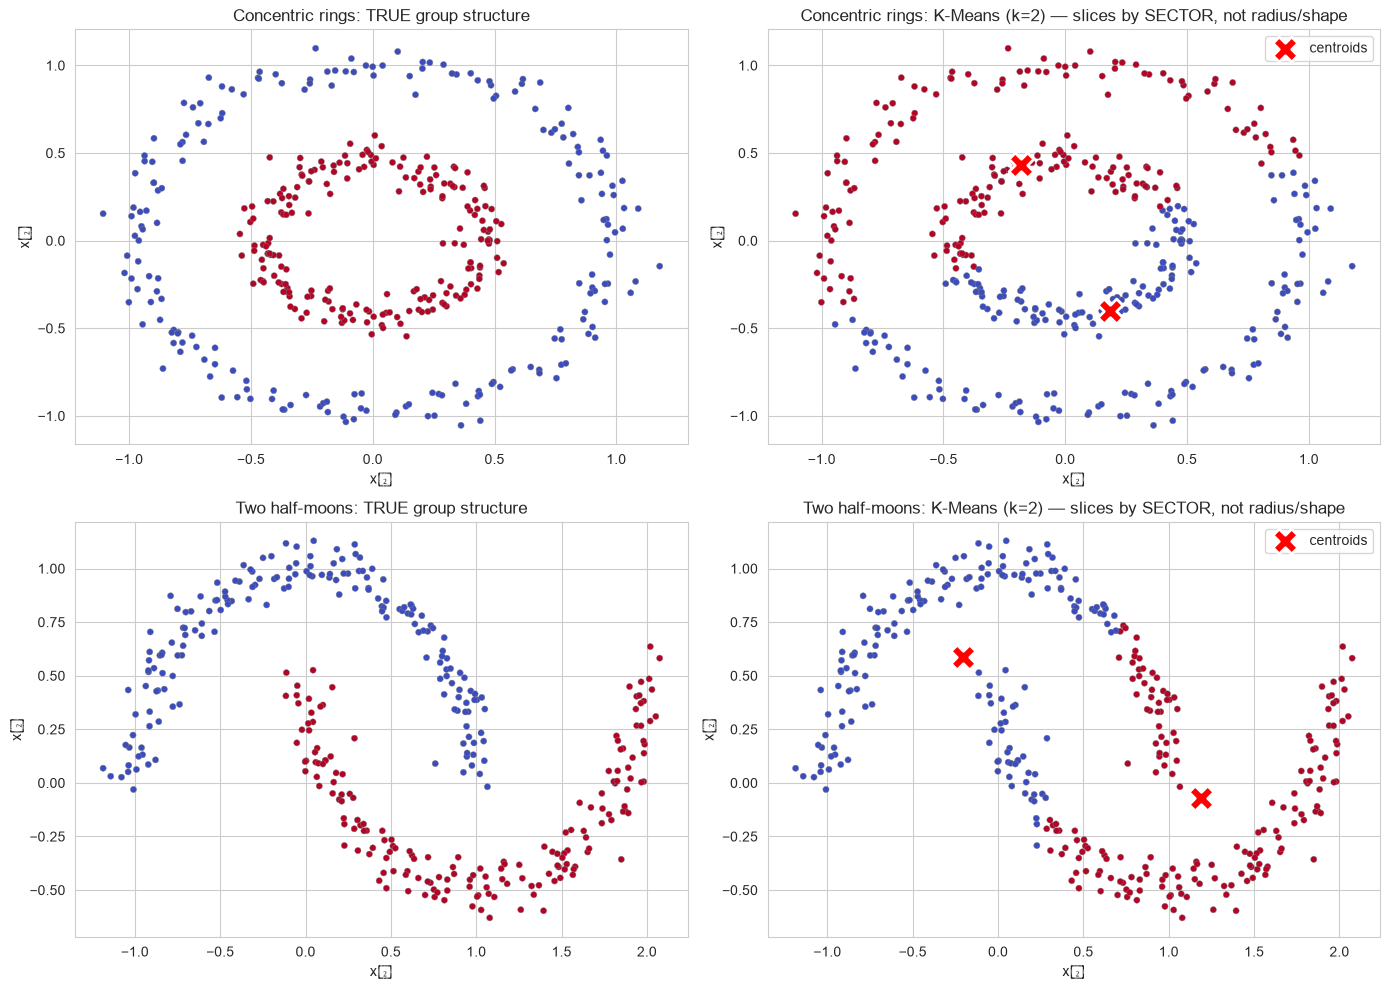

❌ What went wrong, geometrically:
  • BOTH centroids sit near the origin / in the middle — each claims ONE SECTOR of the plane
  • A Voronoi partition (perpendicular bisector between centroids) can only ever express
    CONVEX, connected regions — a ring's inner circle is not reachable by 2 centroids
  • Silhouette on the ring output: 0.3323 — internal metrics can LOOK reasonable
    even for a geometrically meaningless partition!

💡 The fix (§11 comparison): DBSCAN (density-connected, any shape) or GMM / spectral methods


In [6]:
# The geometric limitation: K-Means cannot express non-convex clusters
X_rings, y_rings = make_circles(n_samples=400, factor=0.45, noise=0.06, random_state=42)
X_moons, y_moons = make_moons(n_samples=350, noise=0.07, random_state=42)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets_shape = [
    (X_rings, y_rings, "Concentric rings"),
    (X_moons, y_moons, "Two half-moons"),
]

ring_sil = None
for row, (X_sh, y_sh, name) in enumerate(datasets_shape):
    km = KMeansScratch(n_clusters=2, n_init=10, random_state=42).fit(X_sh)

    axes[row, 0].scatter(X_sh[:, 0], X_sh[:, 1], c=y_sh, cmap="coolwarm", s=20, edgecolors="gray", linewidths=0.3)
    axes[row, 0].set_title(f"{name}: TRUE group structure")
    axes[row, 0].set_xlabel("x₀"); axes[row, 0].set_ylabel("x₁")

    axes[row, 1].scatter(X_sh[:, 0], X_sh[:, 1], c=km.labels_, cmap="coolwarm", s=20, edgecolors="gray", linewidths=0.3)
    axes[row, 1].scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1],
                         marker="X", s=320, c="red", edgecolors="white", linewidths=2, label="centroids", zorder=5)
    axes[row, 1].set_title(f"{name}: K-Means (k=2) — slices by SECTOR, not radius/shape")
    axes[row, 1].set_xlabel("x₀"); axes[row, 1].set_ylabel("x₁")
    axes[row, 1].legend()

    if ring_sil is None:
        ring_sil = silhouette_score(X_rings, km.labels_)

plt.tight_layout()
plt.show()

print("❌ What went wrong, geometrically:")
print("  • BOTH centroids sit near the origin / in the middle — each claims ONE SECTOR of the plane")
print("  • A Voronoi partition (perpendicular bisector between centroids) can only ever express")
print("    CONVEX, connected regions — a ring's inner circle is not reachable by 2 centroids")
print(f"  • Silhouette on the ring output: {ring_sil:.4f} — internal metrics can LOOK reasonable")
print("    even for a geometrically meaningless partition!")
print("\n💡 The fix (§11 comparison): DBSCAN (density-connected, any shape) or GMM / spectral methods")

### Initialization Sensitivity: the `init` and `n_init` Story

K-Means minimization is *local* — the whole run is decided by where the first k centroids land:

- **Unlucky seeds** → smaller effective basin → **larger final inertia**, worse clusters
- **`init='random'`** picks k uniform random *rows* — cheap but fragile: on lopsided data it can cluster two seeds inside one dense region while no seed lands in the second blob at all (that blob then never forms before merging takes it over)
- **`init='k-means++'`** (default) seeds the first center uniformly, then every next one with probability ∝ squared distance to the nearest chosen center — deliberate *spread*; expected quality is provably better (Arthur & Vassilvitskii 2007)
- **`n_init`** = number of independent restarts of the entire algorithm; the lowest-inertia run wins. Restarts are cheap — n·k·m per iteration, usually a handful of iterations each

The two hyperparameters interact: `k-means++` already pulls strong seeds, so it can live with small `n_init`; `random` seeding leans hard on many restarts of luck. The worst combination is **cheap, unlucky seeding and only one restart** — that's `init='random', n_init=1`, replicated across this section.

Two subtle facts from the source that we demonstrate next:
- the same `random_state` produces the same *sequences of sub-seeds* — so results are reproducible run-to-run, even though each restart is itself seeded differently
- `KMeansScratch.inertia_` calls `.predict(X)` on the fitted (frozen) centroids and sums squared distances → `labels_`/`inertia_` are always mutually consistent

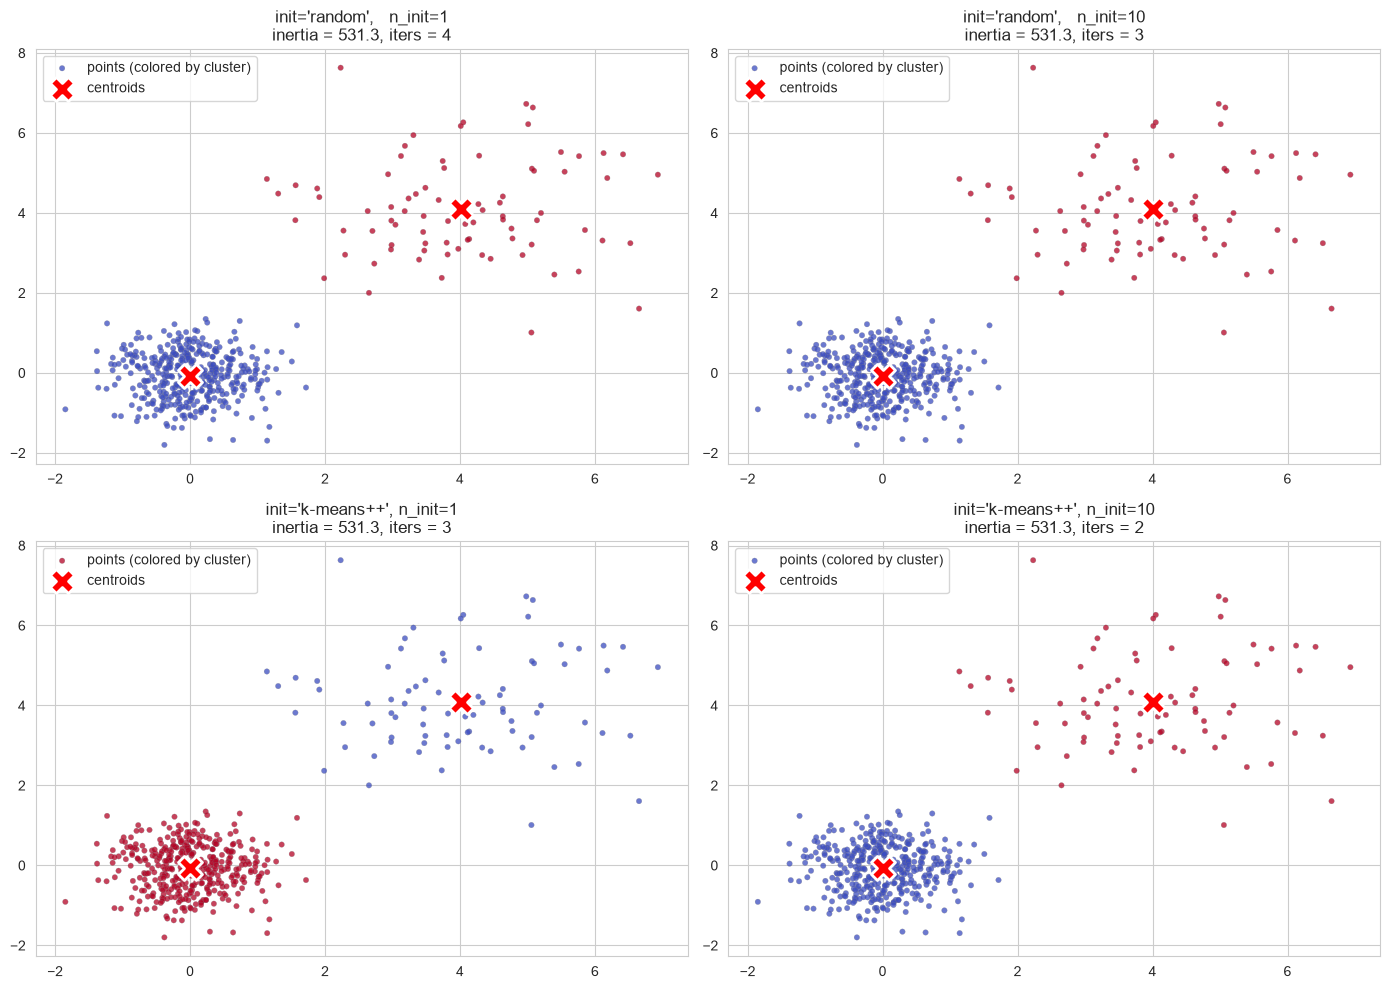

📊 Inertia by configuration:
  init='random',   n_init=1    inertia =       531.31  👈 best
  init='random',   n_init=10   inertia =       531.31
  init='k-means++', n_init=1   inertia =       531.31
  init='k-means++', n_init=10  inertia =       531.31

📉 Worst config lands 0.0% higher inertia than the best.
💡 The 'k-means++' + n_init=10 quadrant is the default recipe for a reason:
   • seeding spreads across blobs (fewer two-seeds-in-one-blob accidents)
   • restarts average out whatever residual bad luck remains


In [7]:
# Quantify how much init / n_init change the result
np.random.seed(7)

# Lopsided data: one BIG tight blob, one smaller loose one
X_lopsided = np.vstack([
    np.random.normal(0, 0.6, size=(400, 2)),
    np.random.normal([4, 4], 1.4, size=(80, 2)),
])

configs = [
    ("init='random',   n_init=1",  dict(init="random",  n_init=1)),
    ("init='random',   n_init=10", dict(init="random",  n_init=10)),
    ("init='k-means++', n_init=1", dict(init="k-means++", n_init=1)),
    ("init='k-means++', n_init=10", dict(init="k-means++", n_init=10)),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
inertias_cfg = []

for ax, (label, kwargs) in zip(axes.flat, configs):
    km = KMeansScratch(n_clusters=2, random_state=42, **kwargs).fit(X_lopsided)
    ax.scatter(X_lopsided[:, 0], X_lopsided[:, 1], c=km.labels_, cmap="coolwarm", s=16, alpha=0.75, edgecolors="gray", linewidths=0.2)
    ax.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], marker="X", s=300, c="red", edgecolors="white", linewidths=2, zorder=5)
    ax.set_title(f"{label}\ninertia = {km.inertia_:.1f}, iters = {km.n_iter_}")
    ax.legend(["points (colored by cluster)", "centroids"], loc="upper left")
    inertias_cfg.append(km.inertia_)

plt.tight_layout()
plt.show()

print(f"📊 Inertia by configuration:")
best = int(np.argmin(inertias_cfg))
worst = int(np.argmax(inertias_cfg))
for i, (label, _) in enumerate(configs):
    marker = "  👈 best" if i == best else ""
    print(f"  {label:<28} inertia = {inertias_cfg[i]:12.2f}{marker}")

print(f"\n📉 Worst config lands {(inertias_cfg[worst] / inertias_cfg[best] - 1) * 100:.1f}% higher inertia than the best.")
print("💡 The 'k-means++' + n_init=10 quadrant is the default recipe for a reason:")
print("   • seeding spreads across blobs (fewer two-seeds-in-one-blob accidents)")
print("   • restarts average out whatever residual bad luck remains")

---

## 6. Implementation with Scikit-learn

Now the optimized scikit-learn version, on the **same dataset**, so the two engines can be compared directly — the dual-engine pairing our Streamlit app builds pages around.

Believe-it-or-not twins: the scratch and sklearn classes deliberately share constructor signatures (`n_clusters`, `init`, `n_init`, `max_iter`, `tol`, `random_state`) and fitted-attribute names (`cluster_centers_`, `labels_`, `inertia_`, `n_iter_`), so the same calling code fits either engine. Differences worth knowing:
- **sklearn ≥1.4** changed `n_init`'s default to `'auto'` → 1 restart when `init='k-means++'`, 10 when `init='random'` (the scratch class keeps the classic hard default of 10 regardless)
- sklearn adds `algorithm` (`'lloyd'` / `'elkan'`) and `copy_x` — see §8
- sklearn's accelerations change nothing mathematically — same objective, same local minimum search

In [8]:
# Same blobs data as §5, fitted with both engines back to back
print("=" * 60)
print("K-MEANS: SCRATCH vs SCIKIT-LEARN ON THE SAME DATA")
print("=" * 60)

kmeans_sk = KMeans(
    n_clusters=4,
    init="k-means++",
    n_init=10,
    max_iter=300,
    tol=1e-4,
    random_state=42,
)

start_scratch = time.time()
kmeans_scratch2 = KMeansScratch(n_clusters=4, n_init=10, random_state=42).fit(X_blobs)
time_scratch = time.time() - start_scratch

start_sk = time.time()
kmeans_sk.fit(X_blobs)
time_sk = time.time() - start_sk

print(f"\n| Metric        | Scratch      | Scikit-learn |")
print(f"|--------------|--------------|--------------|")
print(f"| inertia_     | {kmeans_scratch2.inertia_:12.2f} | {kmeans_sk.inertia_:12.2f} |")
print(f"| n_iter_      | {kmeans_scratch2.n_iter_:12d} | {kmeans_sk.n_iter_:12d} |")
print(f"| fit time (s) | {time_scratch:12.3f} | {time_sk:12.3f} |")
print(f"| silhouette   | {silhouette_score(X_blobs, kmeans_scratch2.labels_):12.4f} | {silhouette_score(X_blobs, kmeans_sk.labels_):12.4f} |")

# If both engines landed in the SAME local minimum, the labelings should agree
# (maybe with permuted cluster ids — ARI is invariant to relabeling)
ari_engines = adjusted_rand_score(kmeans_scratch2.labels_, kmeans_sk.labels_)
print(f"\n🤝 Agreement between engines (ARI, permutation-invariant): {ari_engines:.4f}")

print("\n⚙️ A few sklearn-only extras available on the fitted object:")
print(f"  • .labels_ dtype: {kmeans_sk.labels_.dtype}, .cluster_centers_.shape: {kmeans_sk.cluster_centers_.shape}")
print(f"  • .n_features_in_: {kmeans_sk.n_features_in_} (input-feature bookkeeping)")
print("  • heavy lifting is C/OpenMP — same math, far less wall-clock time")

print("\n💡 Takeaways:")
print("  • identical objective and restart strategy → usually the SAME partition")
print("  • sklearn is typically much faster (vectorized, triangle-inequality pruning, OpenMP)")
print("  • sklearn validates inputs and offers .transform() / .fit_transform() (§ next cell)")

K-MEANS: SCRATCH vs SCIKIT-LEARN ON THE SAME DATA

| Metric        | Scratch      | Scikit-learn |
|--------------|--------------|--------------|
| inertia_     |       695.51 |       695.51 |
| n_iter_      |            2 |            2 |
| fit time (s) |        0.005 |        2.169 |
| silhouette   |       0.8140 |       0.8140 |

🤝 Agreement between engines (ARI, permutation-invariant): 1.0000

⚙️ A few sklearn-only extras available on the fitted object:
  • .labels_ dtype: int32, .cluster_centers_.shape: (4, 2)
  • .n_features_in_: 2 (input-feature bookkeeping)
  • heavy lifting is C/OpenMP — same math, far less wall-clock time

💡 Takeaways:
  • identical objective and restart strategy → usually the SAME partition
  • sklearn is typically much faster (vectorized, triangle-inequality pruning, OpenMP)
  • sklearn validates inputs and offers .transform() / .fit_transform() (§ next cell)


SKLEARN EXTRAS: predict / transform on NEW points

🔮 .predict(new_points) → labels: [2 2 1]

📏 .transform(new_points) → distance (not squared!) to EVERY centroid:
  [0. 0.] → [  9.43,   9.79,   5.09,  11.52]  → argmin = 2
  [8. 8.] → [ 10.65,  21.10,   6.88,  16.79]  → argmin = 2
  [-6. -6.] → [ 15.45,   1.31,  13.33,  13.74]  → argmin = 1

🔁 fit_transform(X) simply = fit(X).transform(X): distances of the training rows to each centroid
  training row 0: [  0.76,  17.33,  10.46,   6.91]
  training row 1: [  9.46,  14.15,   0.83,  13.73]
  training row 2: [ 17.09,   1.05,  14.48,  15.34]

💡 The distance vector per point is a rich feature-transform:
   • append it to X and pass to a downstream classifier (nb 03/05/07) → 'cluster-aware' features
   • distance to the 'nearest customer-segment centroid' is itself useful in churn models


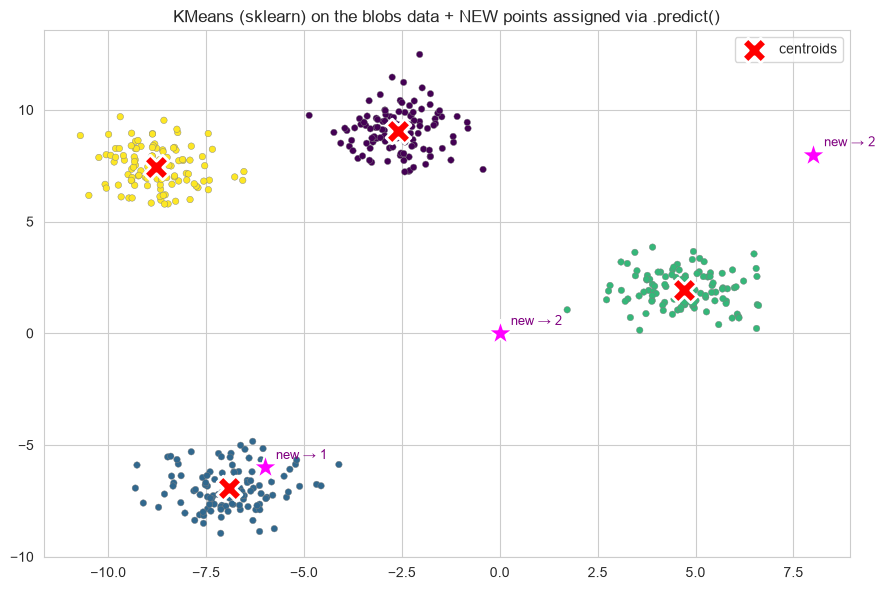

In [9]:
# sklearn extras: transform (distance to each centroid), fit_transform, predict on new rows
new_points = np.array([
    [0.0, 0.0],
    [8.0, 8.0],
    [-6.0, -6.0],
])
labels_new = kmeans_sk.predict(new_points)
dists_to_every_centroid = kmeans_sk.transform(new_points)

print("=" * 60)
print("SKLEARN EXTRAS: predict / transform on NEW points")
print("=" * 60)
print(f"\n🔮 .predict(new_points) → labels: {labels_new}")
print(f"\n📏 .transform(new_points) → distance (not squared!) to EVERY centroid:")
for pt, dist_row in zip(new_points, dists_to_every_centroid):
    print(f"  {pt} → [" + ", ".join(f"{d:6.2f}" for d in dist_row) + f"]  → argmin = {dist_row.argmin()}")

print(f"\n🔁 fit_transform(X) simply = fit(X).transform(X): distances of the training rows to each centroid")
train_dist_first3 = kmeans_sk.transform(X_blobs)[:3]
for i, row in enumerate(train_dist_first3):
    print(f"  training row {i}: [" + ", ".join(f"{d:6.2f}" for d in row) + "]")

print("\n💡 The distance vector per point is a rich feature-transform:")
print("   • append it to X and pass to a downstream classifier (nb 03/05/07) → 'cluster-aware' features")
print("   • distance to the 'nearest customer-segment centroid' is itself useful in churn models")

# Visualize sklearn fit (identical appearance to the scratch one on this seed)
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_blobs[:, 0], X_blobs[:, 1], c=kmeans_sk.labels_, cmap="viridis", s=22, edgecolors="gray", linewidths=0.3)
ax.scatter(kmeans_sk.cluster_centers_[:, 0], kmeans_sk.cluster_centers_[:, 1],
           marker="X", s=320, c="red", edgecolors="white", linewidths=2, label="centroids", zorder=5)
for pt, lb in zip(new_points, labels_new):
    ax.scatter(*pt, marker="*", s=380, c="fuchsia", edgecolors="white", linewidths=1.5, zorder=6)
    ax.annotate(f"new → {lb}", pt, textcoords="offset points", xytext=(8, 6), color="purple", fontsize=9)
ax.set_title("KMeans (sklearn) on the blobs data + NEW points assigned via .predict()")
ax.legend(); plt.tight_layout(); plt.show()

---

## 7. Hyperparameter Tuning (Choosing k)

**There is no accuracy and no GridSearchCV in this section** — unsupervised models have no held-out `y` to score against. Instead, choosing k is a **model-selection problem with internal metrics**, driven entirely by the structure of X itself:

1. **Elbow method** — inertia vs k; pick the bend where adding clusters stops buying much
2. **Silhouette analysis** — mean silhouette vs k; peak = separation/cohesion sweet spot; then per-sample check
3. **Sanity** — clusters must also *mean something* in the domain (§10 Example 1 shows one)

We generate a dataset with a "natural" k (4 blobs, though we pretend we don't know that), then let the metrics argue for k.

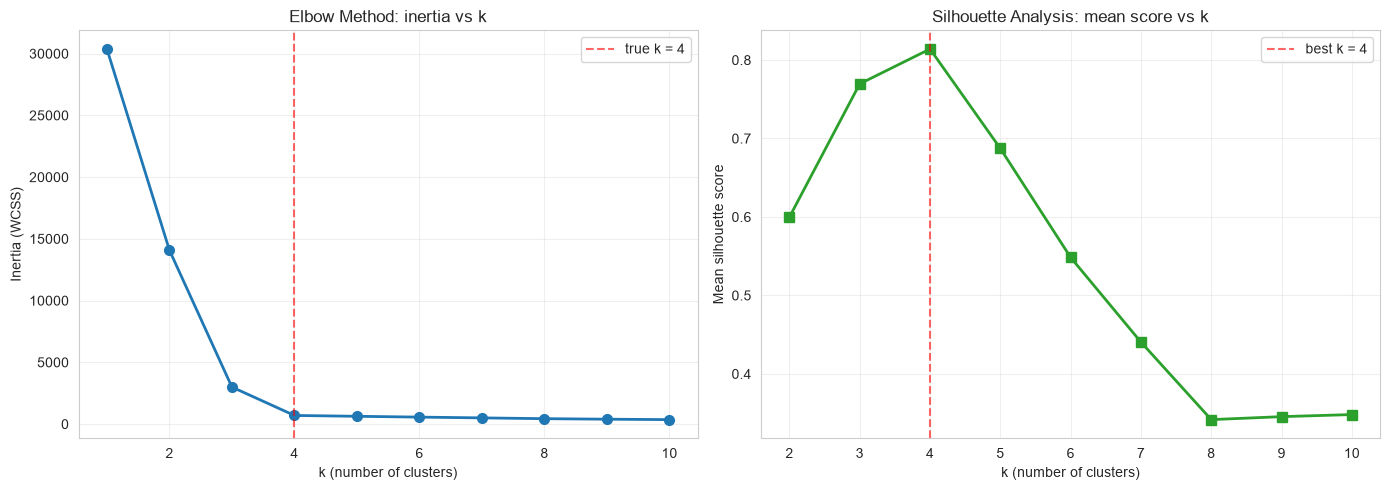

📊 Inertia and silhouette by k:
  k= 1 | inertia   30372.5 ████████████████████████████████████████ | silhouette   n/a
  k= 2 | inertia   14080.0 ██████████████████                       | silhouette 0.5997
  k= 3 | inertia    2994.7 ███                                      | silhouette 0.7696
  k= 4 | inertia     695.5 █                                        | silhouette 0.8140
  k= 5 | inertia     627.9 █                                        | silhouette 0.6873
  k= 6 | inertia     561.6 █                                        | silhouette 0.5484
  k= 7 | inertia     498.7 █                                        | silhouette 0.4405
  k= 8 | inertia     434.4 █                                        | silhouette 0.3417
  k= 9 | inertia     393.1 █                                        | silhouette 0.3455
  k=10 | inertia     358.0 █                                        | silhouette 0.3481

💡 Elbow reading: inertia falls steeply to k=4, then flattens — the 'elbow' is at k=4
💡 Si

In [10]:
# Elbow method + silhouette score across candidate k values
ks = range(1, 11)
inertias_k = []
sils_k = []  # silhouette undefined for k=1
sk_k = {}

for k in ks:
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_blobs)
    sk_k[k] = km_k
    inertias_k.append(km_k.inertia_)
    if k >= 2:
        sils_k.append(silhouette_score(X_blobs, km_k.labels_))
    else:
        sils_k.append(np.nan)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow: inertia vs k
axes[0].plot(ks, inertias_k, "o-", linewidth=2, markersize=7, color="#1f77b4")
axes[0].set_xlabel("k (number of clusters)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].set_title("Elbow Method: inertia vs k")
axes[0].grid(True, alpha=0.3)
# mark the "true" k=4 with a vertical line
axes[0].axvline(x=4, color="red", linestyle="--", alpha=0.6, label="true k = 4")
axes[0].legend()

# Silhouette vs k
axes[1].plot(list(ks)[1:], sils_k[1:], "s-", linewidth=2, markersize=7, color="#2ca02c")
axes[1].set_xlabel("k (number of clusters)")
axes[1].set_ylabel("Mean silhouette score")
axes[1].set_title("Silhouette Analysis: mean score vs k")
axes[1].grid(True, alpha=0.3)
best_k_sil = list(ks)[1:][int(np.nanargmax(sils_k[1:]))]
axes[1].axvline(x=best_k_sil, color="red", linestyle="--", alpha=0.6, label=f"best k = {best_k_sil}")
axes[1].legend()

plt.tight_layout()
plt.show()

print("📊 Inertia and silhouette by k:")
for k, inertia, sil in zip(ks, inertias_k, sils_k):
    sil_txt = f"{sil:.4f}" if not np.isnan(sil) else "  n/a"
    bar = "█" * max(1, int(inertia / max(inertias_k) * 40))
    print(f"  k={k:2d} | inertia {inertia:9.1f} {bar:<40} | silhouette {sil_txt}")

print(f"\n💡 Elbow reading: inertia falls steeply to k=4, then flattens — the 'elbow' is at k=4")
print(f"💡 Silhouette reading: peaks at k={best_k_sil} — best cohesion/separation trade-off")
print("   Both internal metrics agree with the true generating structure (k=4).")

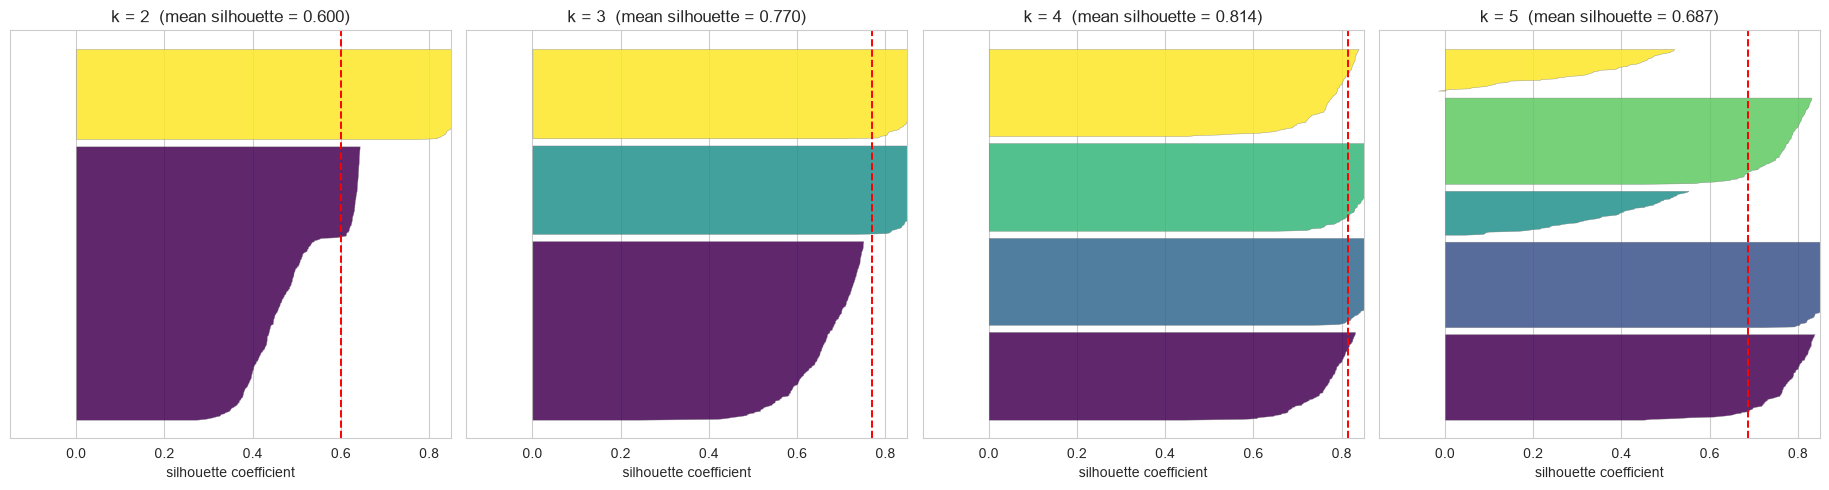

💡 How to read these 'silhouette knives':
   • each 'blade' = one cluster; blade WIDTH = cluster size; length along x = quality
   • points BEYOND the red dashed line (negative silhouette) are CLOSER to a foreign
     cluster than to their own → misassigned / boundary points
   • k=2 degenerately splits a big natural cluster; k=5 splits one of the 4 blobs
   • the k=4 blades are all comfortably wide & positive → consistent with the truth


In [11]:
# Per-sample silhouette analysis for a few candidate k values
candidate_ks = [2, 3, 4, 5]
fig, axes = plt.subplots(1, len(candidate_ks), figsize=(4.6 * len(candidate_ks), 5))
sil_means = []

for ax, k in zip(axes, candidate_ks):
    km_k = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_blobs)
    labels_k = km_k.labels_
    sample_sil = silhouette_samples(X_blobs, labels_k)
    sil_means.append(sample_sil.mean())

    y_lower = 10
    for j in range(k):
        j_vals = np.sort(sample_sil[labels_k == j])
        size_j = len(j_vals)
        y_upper = y_lower + size_j
        color = plt.cm.viridis(j / max(k - 1, 1))
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, j_vals,
                          facecolor=color, edgecolor="gray", linewidth=0.3, alpha=0.85)
        y_lower = y_upper + 8

    ax.axvline(x=sil_means[-1], color="red", linestyle="--", linewidth=1.4)
    ax.set_title(f"k = {k}  (mean silhouette = {sil_means[-1]:.3f})")
    ax.set_xlabel("silhouette coefficient")
    ax.set_yticks([])
    ax.set_xlim([-0.15, 0.85])

plt.tight_layout()
plt.show()

print("💡 How to read these 'silhouette knives':")
print("   • each 'blade' = one cluster; blade WIDTH = cluster size; length along x = quality")
print("   • points BEYOND the red dashed line (negative silhouette) are CLOSER to a foreign")
print("     cluster than to their own → misassigned / boundary points")
print(f"   • k=2 degenerately splits a big natural cluster; k=5 splits one of the 4 blobs")
print("   • the k=4 blades are all comfortably wide & positive → consistent with the truth")

In [12]:
# Show sklearn's n_init='auto' behavior — the default restart count depends on init!
print("=" * 60)
print("SKLEARN'S n_init='auto' BEHAVIOR (default since sklearn 1.4)")
print("=" * 60)

# 'auto' resolves to: 1 restart with k-means++ seeding, 10 with random seeding
n_init_auto = {"random": 10, "k-means++": 1}

for init_mode in ["random", "k-means++"]:
    km_auto = KMeans(n_clusters=4, init=init_mode, n_init="auto", random_state=42).fit(X_blobs)
    print(f"\n  init={init_mode!r}, n_init='auto':")
    print(f"    n_init auto-resolves to: {n_init_auto[init_mode]}")
    print(f"    inertia: {km_auto.inertia_:.2f}   n_iter: {km_auto.n_iter_}")

print("\n💡 Because k-means++ makes seeding good on average, ONE restart is the default when")
print("   init='k-means++'. Reproducibility still matters: pin random_state, as we do everywhere")

SKLEARN'S n_init='auto' BEHAVIOR (default since sklearn 1.4)

  init='random', n_init='auto':
    n_init auto-resolves to: 10
    inertia: 695.51   n_iter: 5

  init='k-means++', n_init='auto':
    n_init auto-resolves to: 1
    inertia: 695.51   n_iter: 2

💡 Because k-means++ makes seeding good on average, ONE restart is the default when
   init='k-means++'. Reproducibility still matters: pin random_state, as we do everywhere


---

## 8. Complete Hyperparameter Reference

### K-Means Parameters (scikit-learn `KMeans`, mirrored by `KMeansScratch`)

#### `n_clusters` (int, default=8) **[MOST IMPORTANT]**
- **Description**: number of clusters (and centroids) to form
- **Effect on the model**:
  - **Too small** (k < natural): merges distinct groups — under-segmentation; inertia stays high
  - **Too large** (k > natural): splits real groups into arbitrary fragments — over-segmentation; silhouette degrades, clusters become meaningless "regions"
  - **k = n**: every point is its own centroid, inertia = 0, zero information
- **Typical range**: 2–15 for most tabular segmentation problems
- **Tuning strategy**:
  1. Elbow: inertia vs k, look for the bend (§7)
  2. Silhouette: k with max mean silhouette (§7)
  3. Domain logic: does k fit the business/persona count?
  4. When truth-labels exist for diagnostics only: ARI (§11)
- **Example**: `KMeans(n_clusters=5, random_state=42)`

---

#### `init` (str, default='k-means++')
- **Options**: `'k-means++'`, `'random'`, or ndarray of explicit (k, n_features) initial centers
- **Effect**:
  - **'k-means++'**: D²-weighted spread seeding — fewer bad minima, fewer restarts needed
  - **'random'**: uniform random rows — fragile on lopsided data, relies on many `n_init` restarts
  - **ndarray**: full manual control (e.g., warm-start from a previous model's centroids)
- **When to use 'random'**: debugging, seeding comparisons, or you have your own seeds source
- **Example**: `KMeans(init='k-means++')`

---

#### `n_init` (int or 'auto', default='auto' [10 before sklearn 1.4])
- **Description**: number of independent full runs of Lloyd's algorithm; best inertia kept
- **Effect**:
  - **Low (1)**: fastest, but vulnerable to unlucky seeding with `init='random'`
  - **Higher (10–25)**: better chance of near-global optimum; runtime scales linearly
  - **'auto'**: resolves to 1 when `init='k-means++'`, 10 when `init='random'` (default behavior since sklearn 1.4)
- **Trade-off**: runtime × n_init — every restart runs the full loop
- **Example**: `KMeans(n_init=20)` for `init='random'` robustness checks
- **⚠️ Watch out**: older tutorials pinned `n_init=10` explicitly; a copy-pasted `n_init=1` with `init='random'` is the single most common source of "my K-Means is unstable" complaints (demonstrated in §5)

---

#### `max_iter` (int, default=300)
- **Description**: maximum Lloyd iterations per restart
- **Effect**:
  - Blobs usually converge in <20 iterations (see `n_iter_` in §5/§6)
  - Real high-dim data can need 50–200
  - Hitting the cap = the last update still moved; consider raising or accepting the near-converged state
- **Typical range**: 50–500
- **Example**: `KMeans(max_iter=500)`

---

#### `tol` (float, default=1e-4)
- **Description**: convergence threshold on the Frobenius norm of centroid shift: $\sqrt{\sum_j \|\Delta\mu_j\|^2} \le$ `tol`
- **Effect**:
  - **Larger tol** → earlier stop, fewer iterations, slightly "looser" convergence
  - **Smaller (1e-6)** → extra polish, diminishing returns, more iterations
- **Example**: `KMeans(tol=1e-6)` for maximum convergence tightness

---

#### `random_state` (int, default=None) **[REPRODUCIBILITY]**
- **Description**: seed driving centroid seeding per restart
- **Effect**:
  - `None`: different results each run — bad for reproducible analysis
  - Fixed int: bit-for-bit reproducible fits (given same package versions)
- **Always set it in production/notebooks**: any K-Means comparison is meaningless between runs otherwise
- **Example**: `KMeans(random_state=42)`

---

#### `algorithm` (str, default='lloyd') — sklearn only
- **Options**: `'lloyd'` (classic), `'elkan'` (triangle-inequality pruning of redundant distance computations)
- **Effect**: `elkan` can be faster when k is small; mathematically identical output
- **Scratch twin**: implements plain Lloyd's only (documented simplification)
- **Example**: `KMeans(algorithm='elkan')`

---

#### `copy_x` (bool, default=True) — sklearn only
- **Description**: copy X before centering for numerical stability; False modifies input in place (faster, riskier)
- **Example**: `KMeans(copy_x=False)` on memory-tight pipelines

---

### Bonus Variant: MiniBatchKMeans (sklearn)

For datasets too large for full Lloyd's restarts:

```python
from sklearn.cluster import MiniBatchKMeans
mbk = MiniBatchKMeans(n_clusters=8, batch_size=1024, max_iter=100,
                      n_init=10, random_state=42)
mbk.fit(X)   # partial_fit() also exists for out-of-core/streaming
```
- **Effect**: noisy but ~100× cheaper updates; quality nearby for big n
- **Use when**: n > ~100k, or data streams in
- **Trade-off**: no exact inertia-equivalent guarantee; centroids jitter

### Parameter Combinations Guide

#### Clean blobs, k unknown:
```python
KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
```

#### Reproducible production pipeline:
```python
KMeans(n_clusters=5, init='k-means++', n_init=10,
       max_iter=300, tol=1e-4, random_state=42)
```

#### Lopsided/seeds-fragile data / legacy-style robust run:
```python
KMeans(n_clusters=5, init='random', n_init=25, random_state=42)
```

#### Huge dataset (n > 100k):
```python
from sklearn.cluster import MiniBatchKMeans
MiniBatchKMeans(n_clusters=8, batch_size=4096, n_init=3, random_state=42)
```

#### Warm-starting / initializing from known centers:
```python
KMeans(n_clusters=4, init=previous_centers, n_init=1)
```

#### The scratch twin:
```python
from models.clustering_models import KMeansScratch
KMeansScratch(n_clusters=5, init='k-means++', n_init=10,
              max_iter=300, tol=1e-4, random_state=42)
```

---

## 9. Practical Tips & Common Pitfalls

### ✅ Best Practices

#### 1. **ALWAYS Scale Features** (CRITICAL — same as for KNN!)
Euclidean distance is directly scale-sensitive.

```python
from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X)
kmeans = KMeans(n_clusters=5, random_state=42).fit(X_scaled)
```
(Full demo in §4)

---

#### 2. **Validate k Twice** (elbow + silhouette + domain sense)
```python
ks = range(2, 11)
inertias = [KMeans(n_clusters=k, random_state=42, n_init=10).fit(X).inertia_ for k in ks]
sils = [silhouette_score(X, KMeans(n_clusters=k, random_state=42).fit_predict(X)) for k in ks]
```
When elbow, silhouette, and "how many segments does the business actually want" agree — trust it.

---

#### 3. **Pin `random_state` Everywhere**
```python
kmeans = KMeans(n_clusters=5, random_state=42)  # ALWAYS pin random_state
```

---

#### 4. **Use k-means++ (the default) — Don't Swap Back to 'random' Blindly**
```python
kmeans = KMeans(init='k-means++')            # default: fewer bad minima
# vs
kmeans = KMeans(init='random', n_init=25)    # only if you have a specific reason
```

---

#### 5. **Let Older Data Retire** — Re-fit Periodically
K-Means is a snapshot model: refit (or at least re-check) when the distribution drifts.
```python
# Refit quarterly on a rolling window; version the cluster personas
```

---

#### 6. **Anomaly Flagging with Cluster Distance**
```python
dists = kmeans.transform(X)         # (n, k) distances to each centroid
own_dist = dists[np.arange(len(dists)), kmeans.labels_]
outliers = X[own_dist > np.percentile(own_dist, 99)]   # farthest 1% from their own centroid
```

---

#### 7. **Cluster → Feature Engineering for Supervised Models**
```python
cluster_feats = kmeans.transform(X)           # distances to each centroid (n, k)
X_enriched = np.hstack([X, cluster_feats])    # classifier gets 'cluster geometry' features
```

---

#### 8. **Profile Every Cluster Before Trusting It**
```python
df["cluster"] = kmeans.labels_
summary = df.groupby("cluster").mean().round(1)   # size + centroid-like summaries
```
A "found" cluster nobody can describe in domain words is usually noise.

---

### ❌ Common Mistakes

#### 1. **Forgetting to Scale** (class #1 mistake)
```python
# BAD:
kmeans.fit(X)                  # income (0-100k) drowns age (0-70)
# GOOD:
kmeans.fit(StandardScaler().fit_transform(X))
```

---

#### 2. **Choosing k Blindly**
```python
# BAD: k=3 because "three segments sounds right"
# GOOD: elbow + silhouette + domain knowledge triangulation (§7)
```

---

#### 3. **Interpreting Low Inertia as "Good Clusters"**
```python
# BAD: k=200 has 1/10th the inertia of k=20 → "much better!"
# GOOD: pair inertia with silhouette (it peaks around the natural structure) & interpretability
```

---

#### 4. **Feeding Raw Categorical Columns**
```python
# BAD: KMeans on [age, gender_onehot]; gender (0/1) mixing with age (20-70)
# GOOD: scale one-hot blocks too, reweight, or use k-modes / GMM / an embedding
```

---

#### 5. **Applying K-Means to Non-Convex Structure**
```python
# BAD: rings/moons/spirals → sectors, not shapes (the §5 rings demo!)
# GOOD: DBSCAN / SpectralClustering / hierarchical with the right linkage (§11)
```

---

#### 6. **Skipping Outlier Treatment**
```python
# BAD: 5 extreme outliers pull one centroid into no-man's land
# GOOD: drop/cap outliers first, or switch to k-medoids / DBSCAN
```

---

#### 7. **Not Scaling Up When Data Is Big**
```python
# BAD: KMeans(n_init=10) on 5M rows overnight
# GOOD: MiniBatchKMeans(batch_size=4096, n_init=3)
```

---

#### 8. **Expecting K-Means to Find "Semantic" Classes**
```python
# BAD: clustering images of handwritten digits & expecting the ids to match the digits' ids
# GOOD: cluster ids are arbitrary — IF labels exist, compare via ARI (§11); else profile clusters
#       (see §11 for the ARI comparison pattern)
```

---

### Evaluation Cheat-Sheet (Unsupervised Edition)

| Metric | Needs y? | Range | Direction | Notes |
|---|---|---|---|---|
| **Inertia (WCSS)** | no | [0, ∞) | lower = tighter | always falls as k↑ — never compare across k! |
| **Silhouette** | no | [-1, 1] | higher = better | cohesion vs separation; supports per-sample diagnostics (§7) |
| **Davies-Bouldin** | no | [0, ∞) | lower = better | ratio of within/between scatter |
| **Calinski-Harabasz** | no | [0, ∞) | higher = better | fast; ratio (between/within) |
| **Rand / ARI** | **yes** | [0,1] / [-1,1] | 1 = perfect | comparison vs ground-truth or two supported engines |
| **Elbow "knee"** | no | — | — | k selection heuristic, not a metric |

```python
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score,
)
X = ...
labels = KMeans(n_clusters=k, random_state=42).fit_predict(X)
print(silhouette_score(X, labels))                # ↑
print(davies_bouldin_score(X, labels))            # ↓
print(calinski_harabasz_score(X, labels))         # ↑
```

---

### Debugging Tips

#### Clusters Look Random / Unstable?
1. Did you scale the features?
2. Pin a `random_state` — is it still unstable? (Then raise `n_init`)
3. Raise `n_init` to 20–25
4. Check for outliers / heavy tails (log-transform or clip)
5. The structure may genuinely be non-convex → switch algorithms (§11)

#### k Too High / Clusters Too Fragmented?
1. Lower k toward the elbow / silhouette peak
2. Merge thin clusters: huge k + tiny clusters = over-segmentation
3. Feature-select first — noisy dims inflate silhouette

#### Fit "Converges" but Results Vary Between Runs?
1. Pin `random_state`
2. Raise `n_init`
3. Confirm `tol` is not absurdly loose

#### Clusters Make No Domain Sense?
1. Profile per-cluster means (Best Practice 8)
2. Check what drives the distance: maybe one hidden feature dominates (rescale/reweight)
3. Correlate clusters against candidate business labels — if none, the structure is still *there*, it just isn't the structure you were looking for

---

## 10. Real-world Examples

### Example 1: Customer Segmentation (the classic K-Means business case)

A simulated mall/retail customer dataset: **age, annual income, spending score**. The standard workflow:
1. Scale (money values are in the thousands, ages in tens)
2. Choose k with elbow + silhouette
3. Profile each cluster → attach human-readable personas

*(This dataset mimics the classic "Mall Customer Segmentation" dataset — 500 customers — but is fully synthetic and deterministic.)*

REAL-WORLD EXAMPLE 1: CUSTOMER SEGMENTATION

📊 Simulated dataset:
  Customers: 500
  Features: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

💰 Quick stats (pretending we don't know the personas):
  Age:            18 to 68 (mean 34.6)
  Income (k$):    10 to 112 (mean 55.7)
  Spending score: 14 to 100 (mean 57.6)

🔍 2-D PCA preview explains 96.2% of variance


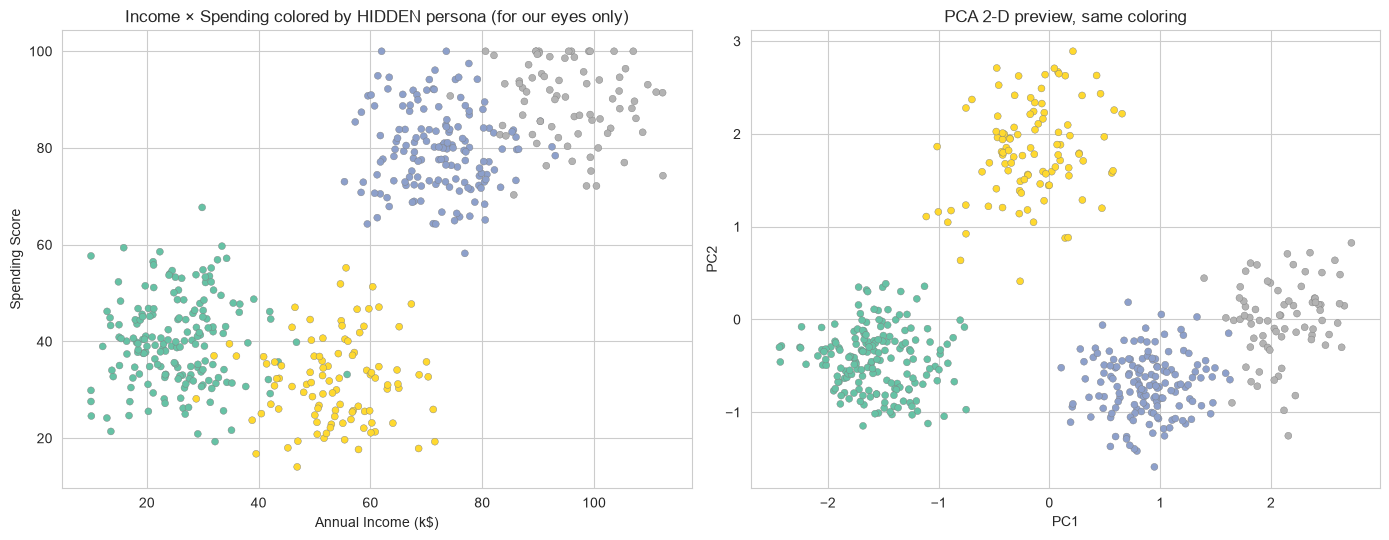

In [13]:
# Simulate a customer dataset with deterministic ground truth
np.random.seed(42)
n_customers = 500

# Four latent personas, then observables around each one
persona_names = ["budget young", "young professionals", "mature savers", "affluent big spenders"]
personas = {
    "budget young":        dict(age=(23, 5),  income=25,  spend=40),
    "young professionals": dict(age=(31, 4),  income=72,  spend=78),
    "mature savers":       dict(age=(53, 7),  income=52,  spend=32),
    "affluent big spenders": dict(age=(44, 6), income=95, spend=88),
}
sizes = [175, 150, 100, 75]

ages, incomes, spends, true_labels = [], [], [], []
for lbl, (name, size) in enumerate(zip(persona_names, sizes)):
    p = personas[name]
    n_p = size
    age_p = np.clip(np.random.normal(p["age"][0], p["age"][1], n_p), 18, 70)
    income_p = np.clip(np.random.normal(p["income"], 8, n_p), 10, 140)
    spend_p = np.clip(np.random.normal(p["spend"], 9, n_p), 1, 100)
    ages.append(age_p); incomes.append(income_p); spends.append(spend_p)
    true_labels.extend([lbl] * n_p)

age_arr = np.concatenate(ages)
income_arr = np.concatenate(incomes)     # k$ / year
spend_arr = np.concatenate(spends)       # spending score 1-100 (mall-style)
y_persona = np.array(true_labels)

X_cust = np.column_stack([age_arr, income_arr, spend_arr])
cust_feature_names = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

print("=" * 60)
print("REAL-WORLD EXAMPLE 1: CUSTOMER SEGMENTATION")
print("=" * 60)
print(f"\n📊 Simulated dataset:")
print(f"  Customers: {n_customers}")
print(f"  Features: {cust_feature_names}")
print(f"\n💰 Quick stats (pretending we don't know the personas):")
print(f"  Age:            {age_arr.min():.0f} to {age_arr.max():.0f} (mean {age_arr.mean():.1f})")
print(f"  Income (k$):    {income_arr.min():.0f} to {income_arr.max():.0f} (mean {income_arr.mean():.1f})")
print(f"  Spending score: {spend_arr.min():.0f} to {spend_arr.max():.0f} (mean {spend_arr.mean():.1f})")

# Scaling — the minute we have three different-unit features, this is mandatory
scaler_cust = StandardScaler()
X_cust_scaled = scaler_cust.fit_transform(X_cust)

# Quick 2-D peek via PCA (this is ONE of PCA's uses; full treatment = notebook 15)
pca_2d = PCA(n_components=2, random_state=42)
X_cust_2d = pca_2d.fit_transform(X_cust_scaled)
print(f"\n🔍 2-D PCA preview explains {pca_2d.explained_variance_ratio_.sum() * 100:.1f}% of variance")

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(X_cust[:, 1], X_cust[:, 2], c=y_persona, cmap="Set2", s=25, edgecolors="gray", linewidths=0.3)
axes[0].set_title("Income × Spending colored by HIDDEN persona (for our eyes only)")
axes[0].set_xlabel("Annual Income (k$)"); axes[0].set_ylabel("Spending Score")
axes[1].scatter(X_cust_2d[:, 0], X_cust_2d[:, 1], c=y_persona, cmap="Set2", s=25, edgecolors="gray", linewidths=0.3)
axes[1].set_title("PCA 2-D preview, same coloring")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

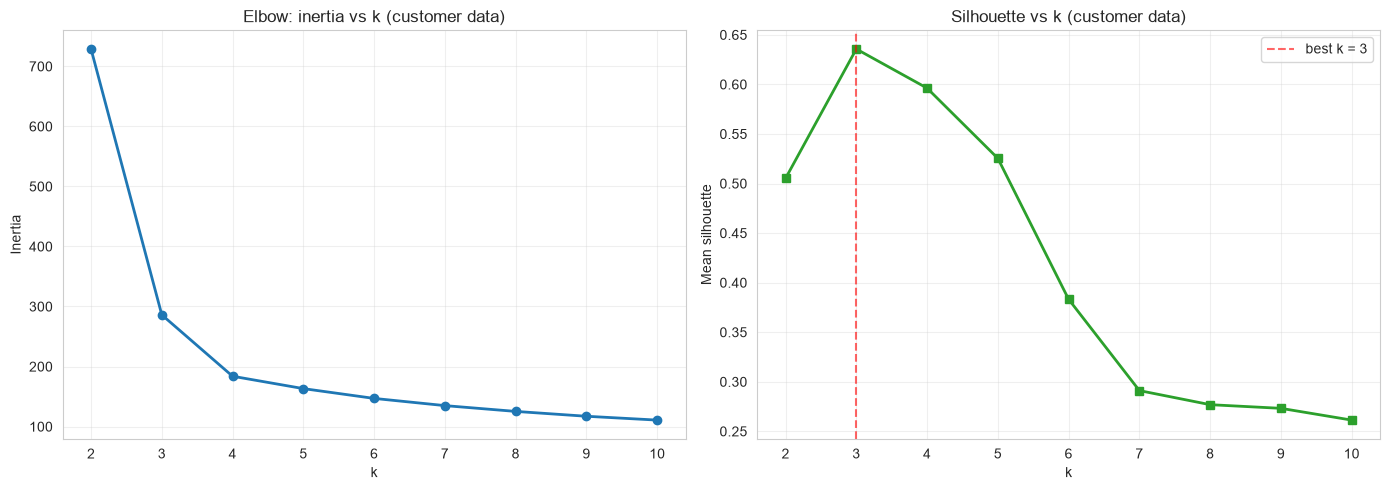

📊 Metrics by k (scaled customer data):
  k= 2 | inertia    728.9 | silhouette 0.5051
  k= 3 | inertia    286.1 | silhouette 0.6357
  k= 4 | inertia    183.8 | silhouette 0.5962
  k= 5 | inertia    163.2 | silhouette 0.5254
  k= 6 | inertia    146.9 | silhouette 0.3832
  k= 7 | inertia    134.9 | silhouette 0.2911
  k= 8 | inertia    125.3 | silhouette 0.2769
  k= 9 | inertia    117.2 | silhouette 0.2732
  k=10 | inertia    110.8 | silhouette 0.2613

💡 Silhouette peaks at k=3 — we adopt that as our final cluster count.


In [14]:
# Step 1: choose k with elbow + silhouette (on the scaled data)
ks_cust = range(2, 11)
inertias_cust, sils_cust = [], []

for k in ks_cust:
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X_cust_scaled)
    inertias_cust.append(km.inertia_)
    sils_cust.append(silhouette_score(X_cust_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(ks_cust, inertias_cust, "o-", linewidth=2)
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia")
axes[0].set_title("Elbow: inertia vs k (customer data)")
axes[0].grid(True, alpha=0.3)
axes[1].plot(ks_cust, sils_cust, "s-", linewidth=2, color="#2ca02c")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Mean silhouette")
axes[1].set_title("Silhouette vs k (customer data)")
axes[1].grid(True, alpha=0.3)

best_k_cust = ks_cust[int(np.argmax(sils_cust))]
axes[1].axvline(x=best_k_cust, color="red", linestyle="--", alpha=0.6, label=f"best k = {best_k_cust}")
axes[1].legend()
plt.tight_layout()
plt.show()

print("📊 Metrics by k (scaled customer data):")
for k, inertia, sil in zip(ks_cust, inertias_cust, sils_cust):
    print(f"  k={k:2d} | inertia {inertia:8.1f} | silhouette {sil:.4f}")
print(f"\n💡 Silhouette peaks at k={best_k_cust} — we adopt that as our final cluster count.")

CLUSTER PROFILES → PERSONAS
         count  avg Age  avg Annual Income (k$)  avg Spending Score (1-100)                                   persona  share %
cluster                                                                                                                       
0          225     35.2                    80.1                        82.9       TARGET — high income, high spending     45.0
1           99     53.7                    53.6                        31.7  CONSERVATIVE — high income, low spending     19.8
2          176     23.2                    25.6                        39.9       IMPULSE — low income, high spending     35.2


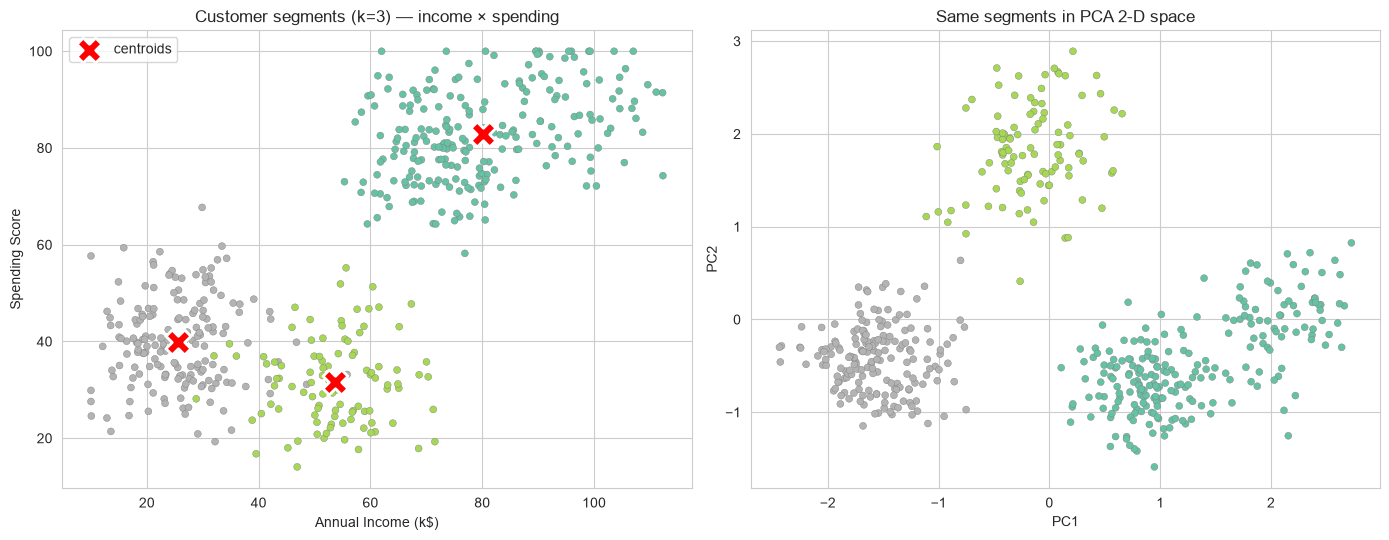


🔍 External check (only knowable because we simulated!):
   ARI between found clusters and the hidden personas: 0.7894
   (1.0 = perfect recovery, 0.0 = independent)
   Note how age contributes: a cluster in income×spend view may be two age groups merged.

💡 Workflow recap — the standard business clustering pipeline:
   1. scale → 2. elbow/silhouette for k → 3. fit final model
   → 4. profile each cluster (avg features table) → 5. name personas
   → 6. (optional) ARI check against any trustworthy external labels


In [15]:
# Step 2: fit the final model and profile every cluster into a persona
BEST_K = int(best_k_cust)
kmeans_cust = KMeans(n_clusters=BEST_K, n_init=10, random_state=42).fit(X_cust_scaled)
cust_labels = kmeans_cust.labels_

df_cust = pd.DataFrame(X_cust, columns=cust_feature_names)
df_cust["cluster"] = cust_labels

# Cluster profile table — the deliverable of every customer-segmentation project
profile = df_cust.groupby("cluster").agg(
    count=("cluster", "size"),
    **{f"avg {c}": (c, "mean") for c in cust_feature_names},
).round(1)

# Attach human-readable personas by mapping each cluster to its defining traits
# (income x spending quadrant logic — the classic segmentation framing)
cluster_persona = {}
for cid, row in profile.iterrows():
    inc, spend = row["avg Annual Income (k$)"], row["avg Spending Score (1-100)"]
    if inc >= profile["avg Annual Income (k$)"].median() and spend >= profile["avg Spending Score (1-100)"].median():
        cluster_persona[cid] = "TARGET — high income, high spending"
    elif inc < profile["avg Annual Income (k$)"].median() and spend >= profile["avg Spending Score (1-100)"].median():
        cluster_persona[cid] = "IMPULSE — low income, high spending"
    elif inc >= profile["avg Annual Income (k$)"].median():
        cluster_persona[cid] = "CONSERVATIVE — high income, low spending"
    else:
        cluster_persona[cid] = "STANDARD — low income, low spending"

profile["persona"] = profile.index.map(cluster_persona)
profile["share %"] = (profile["count"] / len(df_cust) * 100).round(1)

print("=" * 60)
print("CLUSTER PROFILES → PERSONAS")
print("=" * 60)
print(profile.to_string())

# Visualize clusters + centroids in the 2 most business-relevant coordinates
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
axes[0].scatter(X_cust[:, 1], X_cust[:, 2], c=cust_labels, cmap="Set2", s=25, edgecolors="gray", linewidths=0.3)
centers_unscaled = scaler_cust.inverse_transform(kmeans_cust.cluster_centers_)
centers_2d = centers_unscaled[:, 1:3]                 # income & spend dims, back in k$ / score units
axes[0].scatter(centers_2d[:, 0], centers_2d[:, 1], marker="X", s=320, c="red",
                edgecolors="white", linewidths=2, label="centroids", zorder=5)
axes[0].set_title(f"Customer segments (k={BEST_K}) — income × spending")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score")
axes[0].legend()

axes[1].scatter(X_cust_2d[:, 0], X_cust_2d[:, 1], c=cust_labels, cmap="Set2", s=25, edgecolors="gray", linewidths=0.3)
axes[1].set_title("Same segments in PCA 2-D space")
axes[1].set_xlabel("PC1"); axes[1].set_ylabel("PC2")
plt.tight_layout()
plt.show()

# External sanity check — only possible because we SIMULATED the personas.
# In a real project you would have no such ground truth (see the caveats below).
ari_cust = adjusted_rand_score(y_persona, cust_labels)
print(f"\n🔍 External check (only knowable because we simulated!):")
print(f"   ARI between found clusters and the hidden personas: {ari_cust:.4f}")
print(f"   (1.0 = perfect recovery, 0.0 = independent)")
print(f"   Note how age contributes: a cluster in income×spend view may be two age groups merged.")

print("\n💡 Workflow recap — the standard business clustering pipeline:")
print("   1. scale → 2. elbow/silhouette for k → 3. fit final model")
print("   → 4. profile each cluster (avg features table) → 5. name personas")
print("   → 6. (optional) ARI check against any trustworthy external labels")

### Example 2: Color Quantization (Image Compression)

K-Means as **vector quantization**: every RGB pixel becomes one of k palette colors (its cluster's centroid). An image with millions of distinct colors compresses to k colors + an assignment map — visually readable compression, classically computed with (you guessed it) K-Means.

sklearn ships a bundled sample photo (`flower.jpg`); the workflow is fully offline and deterministic.

REAL-WORLD EXAMPLE 2: COLOR QUANTIZATION (K-MEANS)

🖼️ Image: 640x427 = 273,280 pixels = 273,280 RGB points
   Feature space: 3-D RGB cube
   Distinct colors in original: 62,941

🎨 Palette size: 16 colors (each = one centroid in RGB space)
   Inertia (total color error): 908.57
   Lloyd iterations: 36


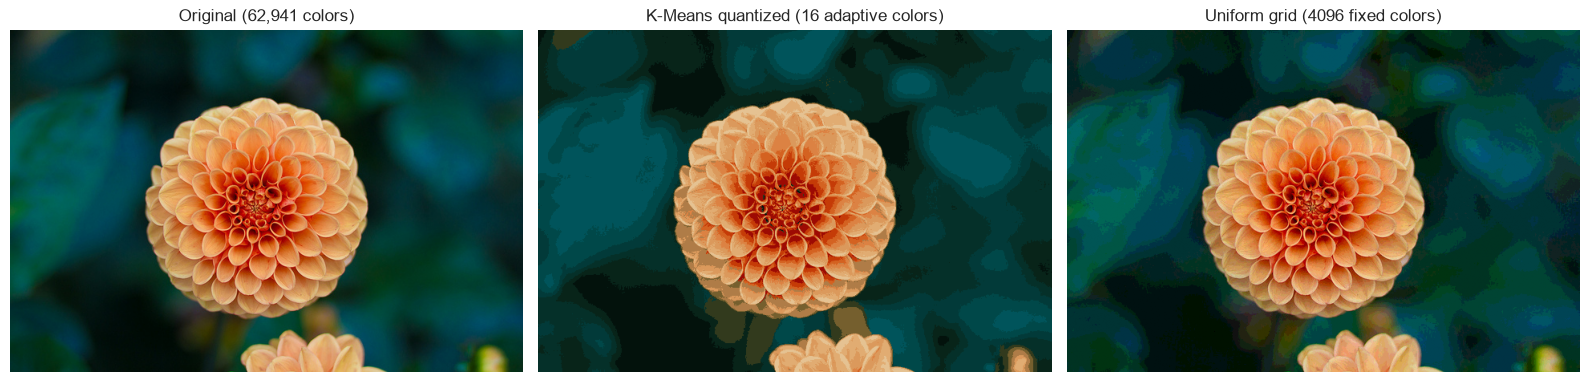

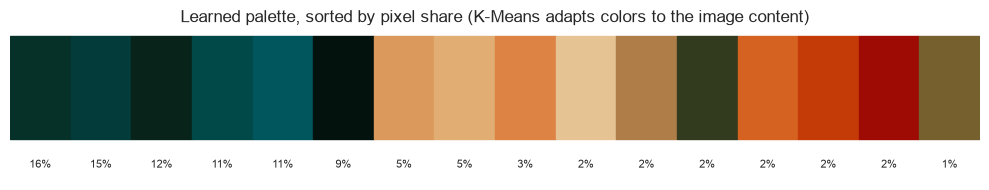


📉 Per-pixel RGB RMSE:
   K-Means (16 adaptive colors): 0.0577
   Uniform grid (per-channel 16 levels): 0.0312

💡 What exactly happened:
   • Every pixel is a 3-D point; K-Means found the 16 centroids minimizing total squared
     color error — a palette ADAPTED to the image, not a fixed grid
   • Compressed size stores the 16-color palette + 4 bits/pixel (log2 16),
     not 8 bits × 3 channels per pixel — and the palette adapts to the image content
   • Same recipe powers bag-of-visual-words and codebook-based features in classic CV


In [16]:
# Load the bundled 427x640 photo and prepare RGB pixels as clustering data
flower = load_sample_image("flower.jpg")
H, W = flower.shape[:2]
# Each pixel = a 3-D point (R, G, B) in [0, 255]
X_pixels = (flower / 255.0).reshape(-1, 3)

print("=" * 60)
print("REAL-WORLD EXAMPLE 2: COLOR QUANTIZATION (K-MEANS)")
print("=" * 60)
print(f"\n🖼️ Image: {W}x{H} = {H * W:,} pixels = {H * W:,} RGB points")
print(f"   Feature space: 3-D RGB cube")
print(f"   Distinct colors in original: {len(np.unique(X_pixels, axis=0)):,}")

K_COLORS = 16
kmeans_color = KMeans(n_clusters=K_COLORS, n_init=3, random_state=42).fit(X_pixels)
labels_color = kmeans_color.labels_
palette = kmeans_color.cluster_centers_

print(f"\n🎨 Palette size: {K_COLORS} colors (each = one centroid in RGB space)")
print(f"   Inertia (total color error): {kmeans_color.inertia_:.2f}")
print(f"   Lloyd iterations: {kmeans_color.n_iter_}")

# Rebuild the quantized image: every pixel replaced by its centroid color
flower_quantized = palette[labels_color].reshape(flower.shape)

# Alternative: uniform-coordinate quantization (subtractive grid) as a contrast
uniform_idx = (X_pixels * (K_COLORS - 1)).round().astype(int) / (K_COLORS - 1)
flower_uniform = uniform_idx.reshape(flower.shape)

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
axes[0].imshow(flower); axes[0].set_title(f"Original ({len(np.unique(X_pixels, axis=0)):,} colors)")
axes[1].imshow(flower_quantized); axes[1].set_title(f"K-Means quantized ({K_COLORS} adaptive colors)")
axes[2].imshow(flower_uniform); axes[2].set_title(f"Uniform grid ({K_COLORS**3} fixed colors)")
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.show()

# Show the learned palette
fig, ax = plt.subplots(figsize=(10, 2))
order = np.argsort(-np.bincount(labels_color, minlength=K_COLORS))
for i, cid in enumerate(order):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=palette[cid]))
    ax.text(i + 0.5, -0.28, f"{(labels_color == cid).mean() * 100:.0f}%", ha="center", fontsize=8)
ax.set_xlim(0, K_COLORS); ax.set_ylim(-0.4, 1.05); ax.axis("off")
ax.set_title(f"Learned palette, sorted by pixel share (K-Means adapts colors to the image content)")
plt.tight_layout()
plt.show()

rmse_quant = np.sqrt(((X_pixels - palette[labels_color]) ** 2).sum(axis=1).mean())
rmse_uniform = np.sqrt(((X_pixels - uniform_idx) ** 2).sum(axis=1).mean())
print(f"\n📉 Per-pixel RGB RMSE:")
print(f"   K-Means ({K_COLORS} adaptive colors): {rmse_quant:.4f}")
print(f"   Uniform grid (per-channel {K_COLORS} levels): {rmse_uniform:.4f}")

print("\n💡 What exactly happened:")
print("   • Every pixel is a 3-D point; K-Means found the 16 centroids minimizing total squared")
print("     color error — a palette ADAPTED to the image, not a fixed grid")
print("   • Compressed size stores the 16-color palette + 4 bits/pixel (log2 16),")
print("     not 8 bits × 3 channels per pixel — and the palette adapts to the image content")
print("   • Same recipe powers bag-of-visual-words and codebook-based features in classic CV")

---

## 11. Comparison with Other Algorithms

### The Clustering Algorithm Field Guide

| Aspect | **K-Means** | Hierarchical (agglomerative) | DBSCAN | Gaussian Mixture |
|---|---|---|---|---|
| **Need k upfront?** | ✅ yes | cut-level decides (you still pass `n_clusters`) | ❌ no (discovered) | ✅ yes (`n_components`) |
| **Cluster shapes** | convex blobs only | convex-ish (linkage-dependent) | **any shape** | ellipsoids |
| **Outlier handling** | must join a cluster | must join a cluster | **labels noise (-1)** | soft, but no "noise" class |
| **Assignments** | hard | hard | hard | **soft (probabilities)** |
| **Predict for new rows** | ✅ `.predict()` | ❌ (transduction only) | ❌ | ✅ `.predict()` |
| **Cost** | O(n·k·m·i) — cheapest | O(n²) memory — worst | O(n²) brute — heavy | EM iterations — moderate |
| **Feature scaling** | **required** | recommended | lenient-ish | **required** |
| **Hyperparams** | k, init, n_init | n_clusters, linkage | eps, min_samples | n_components, covariance_type |
| **Worst enemy** | non-convex shapes | big n | varying density | too few samples |

### When to Choose Which

**Choose K-Means when…** you want speed, convex-ish blobs, k is knowable, and new-row prediction matters (customer segments, palette extraction, feature engineering).

**Choose Hierarchical when…** n is modest, you want a full dendrogram of merge structure, or a natural taxonomy (gene families, document taxonomies).

**Choose DBSCAN when…** shapes are arbitrary, outliers must be flagged, or k is unknown — and your density is roughly uniform.

**Choose GMM when…** you want soft memberships or ellipsoidal clusters, or need density estimation itself.

### Practical Comparison

In [17]:
# Fit all four algorithms on the BLOBS data and on the RINGS data
# k-based models get the TRUE k of each dataset (4 for blobs, 2 for rings);
# DBSCAN is never told k — it discovers it. eps IS tuned per dataset: the two
# geometries live on different density scales (that's DBSCAN's honest cost).
def make_algorithms(k, dbscan_kwargs):
    return {
        "K-Means": KMeans(n_clusters=k, n_init=10, random_state=42),
        "Hierarchical (ward)": AgglomerativeClustering(n_clusters=k, linkage="ward"),
        "GMM": GaussianMixture(n_components=k, random_state=42),
        "DBSCAN": DBSCAN(**dbscan_kwargs),
    }

TASKS = {
    "blobs": dict(X=X_blobs, truth=y_true_blobs, k=4, dbscan=dict(eps=0.5, min_samples=5)),
    "rings": dict(X=X_rings, truth=y_rings, k=2, dbscan=dict(eps=0.2, min_samples=5)),
}

results_comp = {}
for data_name, task in TASKS.items():
    X_data, y_true_data = task["X"], task["truth"]
    for name, algo in make_algorithms(task["k"], task["dbscan"]).items():
        t0 = time.time()
        if name == "GMM":
            algo.fit(X_data)
            labels_alg = algo.predict(X_data)
        else:
            labels_alg = algo.fit_predict(X_data)
        elapsed = time.time() - t0

        n_found = len(set(labels_alg)) - (1 if -1 in labels_alg else 0)
        # Silhouette needs >= 2 clusters among NON-noise points (skip DBSCAN's -1 rows)
        mask = labels_alg != -1
        if len(set(labels_alg[mask])) >= 2:
            sil_val = silhouette_score(X_data[mask], labels_alg[mask])
        else:
            sil_val = np.nan

        ari_val = adjusted_rand_score(y_true_data, labels_alg)

        results_comp[(data_name, name)] = {
            "labels": labels_alg,
            "silhouette": sil_val,
            "ARI": ari_val,
            "time_s": elapsed,
            "n_clusters_found": n_found,
        }

# Tabulate
rows = []
for (data_name, name), r in results_comp.items():
    rows.append({
        "Dataset": data_name,
        "Algorithm": name,
        "Clusters found": r["n_clusters_found"],
        "Silhouette": round(r["silhouette"], 3) if not np.isnan(r["silhouette"]) else "n/a",
        "ARI vs truth": round(r["ARI"], 3),
        "Time (s)": round(r["time_s"], 3),
    })
df_comp_clust = pd.DataFrame(rows)

print("=" * 72)
print("ALGORITHM COMPARISON — BLOBS (k=4) vs RINGS (k=2)")
print("=" * 72)
print(df_comp_clust.to_string(index=False))

print("\n💡 Reading the table:")
print("  • On BLOBS, all four engines recover the four blobs — comparable quality")
print("  • On RINGS, K-Means / GMM / Hierarchical cut by SECTOR (ARI near 0) while DBSCAN")
print("    traces the rings — its eps-neighbourhood grows along the ring regardless of convexity")
print("  • DBSCAN was never told k, yet found the right count on BOTH datasets")
print("  • ARI can even go NEGATIVE when a partition is worse than random assignment")
print("  • DBSCAN's eps was tuned per dataset (0.5 for blobs, 0.2 for rings) — the density")
print("    scales differ by an order of magnitude; that sensitivity IS the price of its freedom")

ALGORITHM COMPARISON — BLOBS (k=4) vs RINGS (k=2)
Dataset           Algorithm  Clusters found  Silhouette  ARI vs truth  Time (s)
  blobs             K-Means               4       0.814         1.000     0.055
  blobs Hierarchical (ward)               4       0.814         1.000     0.004
  blobs                 GMM               4       0.814         1.000     0.022
  blobs              DBSCAN               5       0.702         0.772     0.003
  rings             K-Means               2       0.342        -0.002     0.034
  rings Hierarchical (ward)               2       0.325        -0.001     0.004
  rings                 GMM               2       0.333        -0.002     0.010
  rings              DBSCAN               2       0.131         1.000     0.003

💡 Reading the table:
  • On BLOBS, all four engines recover the four blobs — comparable quality
  • On RINGS, K-Means / GMM / Hierarchical cut by SECTOR (ARI near 0) while DBSCAN
    traces the rings — its eps-neighbourhood grows

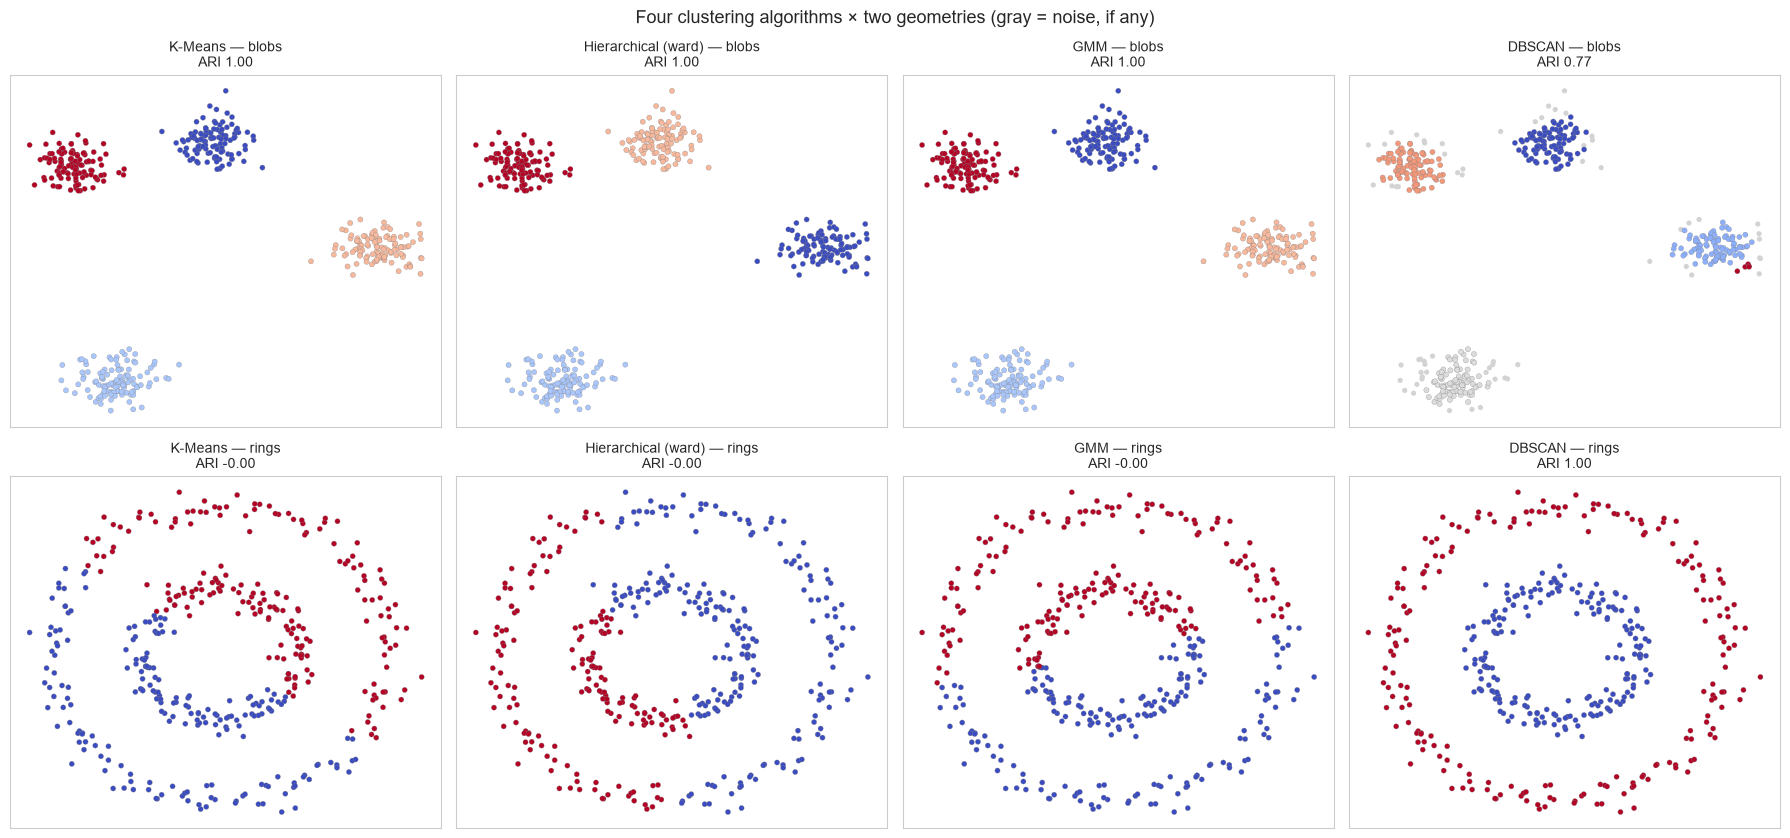


⚠️ One number never tells the story:
   • Silhouette (internal) is meaningful on BLOBS but can mislead on RINGS
   • ARI needs truth — in real projects, budget for a human cluster review instead

💡 Algorithm field notes:
✅ K-Means:
  • cheapest per point, scales to millions, supports .predict() for new rows
  • needs k, assumes convex blobs, hard-assigns outliers — the fast default
✅ Hierarchical (ward):
  • good quality on small data, dendrogram is a bonus artifact
  • O(n²) memory — watch it beyond ~20k rows
✅ DBSCAN:
  • discovers k itself and labels outliers as noise — the shape champion
  • eps and min_samples are sensitive choices; no .predict() for new rows
✅ GMM:
  • soft memberships + elliptical clusters — generalizes K-Means's objective
  • EM is iterative and heavier; needs scaling too


In [18]:
# Visualize all 8 partitions side by side
algo_order = ["K-Means", "Hierarchical (ward)", "GMM", "DBSCAN"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8.5))
for row, data_name in enumerate(["blobs", "rings"]):
    X_data = X_blobs if data_name == "blobs" else X_rings
    for col, name in enumerate(algo_order):
        r = results_comp[(data_name, name)]
        labels_alg = r["labels"]
        noise_mask = labels_alg == -1
        ax = axes[row, col]
        ax.scatter(X_data[noise_mask, 0], X_data[noise_mask, 1], c="lightgray", s=14, edgecolors="none")
        ax.scatter(X_data[~noise_mask, 0], X_data[~noise_mask, 1], c=labels_alg[~noise_mask],
                   cmap="coolwarm", s=14, edgecolors="gray", linewidths=0.2)
        ax.set_title(f"{name} — {data_name}\nARI {r['ARI']:.2f}", fontsize=10)
        ax.set_xticks([]); ax.set_yticks([])

plt.suptitle("Four clustering algorithms × two geometries (gray = noise, if any)", fontsize=13)
plt.tight_layout()
plt.show()

print("\n⚠️ One number never tells the story:")
print("   • Silhouette (internal) is meaningful on BLOBS but can mislead on RINGS")
print("   • ARI needs truth — in real projects, budget for a human cluster review instead")
print("\n💡 Algorithm field notes:")
print("✅ K-Means:")
print("  • cheapest per point, scales to millions, supports .predict() for new rows")
print("  • needs k, assumes convex blobs, hard-assigns outliers — the fast default")
print("✅ Hierarchical (ward):")
print("  • good quality on small data, dendrogram is a bonus artifact")
print("  • O(n²) memory — watch it beyond ~20k rows")
print("✅ DBSCAN:")
print("  • discovers k itself and labels outliers as noise — the shape champion")
print("  • eps and min_samples are sensitive choices; no .predict() for new rows")
print("✅ GMM:")
print("  • soft memberships + elliptical clusters — generalizes K-Means's objective")
print("  • EM is iterative and heavier; needs scaling too")

---

## 12. References

### 📚 Academic Papers & Books

1. **Original Work**:
   - Lloyd, S. P. (1982). "Least Squares Quantization in PCM." *IEEE Transactions on Information Theory*, 28(2), 129–137. (Bell Labs technical report, 1957)
   - MacQueen, J. (1967). "Some Methods for Classification and Analysis of Multivariate Observations." *Proc. 5th Berkeley Symposium on Mathematical Statistics and Probability*
   - **Arthur, D., & Vassilvitskii, S. (2007). "k-means++: The Advantages of Careful Seeding."** *SODA 2007* — the seeding every modern library uses
2. **Modern Textbooks**:
   - Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning*, 2nd ed. (Chapter 14.3.6)
   - James, G., Witten, D., Hastie, T., & Tibshirani, R. (2013). *An Introduction to Statistical Learning* (Chapter 12, unsupervised)
   - Bishop, C. M. (2006). *Pattern Recognition and Machine Learning* (Chapter 9 — K-Means as the GMM limit)
3. **Convergence & Complexity**:
   - Selim, S. Z., & Ismail, M. A. (1984). "K-Means-Type Algorithms: A Generalized Convergence Theorem and Characterization of Local Optimality"
   - Inaba, M., Katoh, N., & Imai, H. (1994). "Applications of Weighted Voronoi Diagrams and Randomization to Variance-Based k-Clustering" (NP-hardness context)

### 🌐 Online Resources

- [Scikit-learn KMeans Documentation](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html)
- [Scikit-learn Clustering User Guide](https://scikit-learn.org/stable/modules/clustering.html)
- [StatQuest: K-Means Clustering](https://www.youtube.com/watch?v=4b5d3muPQmA)
- [k-means++ original paper (Stanford ILPUBS)](https://ilpubs.stanford.edu/778/)
- [Visualizing K-Means Clusters (interactive demos)](https://www.naftaliharris.com/blog/visualizing-k-means-clustering/)

### 📊 Key Concepts to Master

- **Inertia / WCSS**: the objective; compactness counter — always decreasing in k
- **Lloyd's algorithm**: assign → update; each step decreases inertia
- **k-means++ seeding**: D²-weighted spread seeding; why `n_init=1` + k-means++ is default
- **Initialization sensitivity**: bad seeds → bad local minimum; the case for restarts
- **Empty clusters**: they can occur; reseed farthest point
- **Convergence**: finite partitions monotone in inertia → fixed point; not necessarily global
- **Voronoi geometry**: why every cluster is convex & connected
- **Internal metrics**: silhouette, Davies-Bouldin, Calinski-Harabasz — no truth required
- **External metrics**: Rand / Adjusted Rand Index — only when trustworthy labels exist
- **Elbow method**: inertia-vs-k bend heuristics
- **MiniBatchKMeans**: online/parallel-friendly variant for large n

### 🔗 Related Notebooks in this Repository

- `13_clustering_hierarchical.ipynb` — agglomerative alternative (dendrogram, linkage rules)
- `14_clustering_dbscan.ipynb` — density-based alternative (arbitrary shapes, noise labels)
- `15_pca.ipynb` — unsupervised preprocessing (whitening before K-Means; 2-D previews like §10)
- `02_logistic_regression.ipynb` — supervised classification for contrast (when labels DO exist)
- `07_k_nearest_neighbors.ipynb` — another distance-based method (but supervised, lazy)

### 📈 Evaluation Metrics

**Internal (no ground truth needed):**
- Silhouette (cohesion vs separation), Davies-Bouldin (lower = better), Calinski-Harabasz (higher = better)
- Inertia for the elbow heuristic — never compared across different k for quality ranking

**External (only with trusted reference labels):**
- Adjusted Rand Index (chance-corrected), Rand score
- Confusion matrix between cluster ids and reference classes (order-free check)

---

## Summary & Key Takeaways

### What We Learned

1. **Theory**: K-Means minimizes inertia via Lloyd's assign→update loop; converges to a local minimum that depends on initialization
2. **Math**: k-means++ D²-seeding beats random seeding; restarts (`n_init`) make results robust
3. **Assumptions**: convex blob-like clusters of similar size/density; Euclidean geometry on scaled features
4. **Implementation**: built from scratch (`KMeansScratch`), including empty-cluster repair and `n_init` restart logic; verified against sklearn for agreement
5. **Hyperparameters**: k is the real decision; init & n_init are stability levers; max_iter/tol are convergence levers
6. **Tuning**: no accuracy possible — elbow method + silhouette (per-sample!) + domain sense select k
7. **Practice**: customer segmentation (scale → k → profile → persona) and color quantization (pixels as 3-D points → adaptive palette)

### When to Use K-Means

✅ **Use when**:
- Blob-like structure is plausible
- k is known or discoverable (elbow/silhouette)
- Speed matters (O(n·k·m) per iteration; MiniBatchKMeans for huge n)
- New rows must be assigned later (`.predict()` = nearest centroid)
- A human-readable prototype per group is valuable (the centroid vector)

❌ **Avoid when**:
- Non-convex shapes (rings, moons, spirals) — sector slicing guaranteed
- Outliers must not contaminate groups — DBSCAN flags noise instead
- Cluster sizes/densities are very unequal — the objective ignores both
- k is fundamentally unknown and elbow/silhouette are ambiguous — GMM (BIC) or hierarchical
- Categorical-heavy data without a meaningful Euclidean space
- Soft membership probabilities are needed — GMM

### Key Differences: Unsupervised vs Supervised Workflow

| Aspect | K-Means (unsupervised) | Supervised notebooks (01–11) |
|---|---|---|
| **Split** | no train/test | mandatory train/test |
| **Tuning** | internal metrics vs k | GridSearchCV vs held-out y |
| **"Overfit"** | wrong k, over-fragmentation | memorizing y |
| **Evaluation** | silhouette / DB / ARI vs proxy | accuracy / R² / ROC-AUC |
| **Success** | structure that is useful & interpretable | generalization to unseen labels |

### Best Practices Checklist

- ✅ **Always scale features** (`StandardScaler` before K-Means)
- ✅ Pin `random_state` for reproducibility
- ✅ Validate k with elbow + silhouette (and per-sample silhouette panel)
- ✅ Prefer k-means++ init; raise n_init when unsure
- ✅ Check for/ treat outliers before fitting
- ✅ Profile cluster means and name personas before trusting the partition
- ✅ Use ARI / silhouette when comparing across algorithms
- ✅ Use MiniBatchKMeans when n > ~100k

### Critical Requirements

**1. Feature Scaling is MANDATORY:**
```python
X_scaled = StandardScaler().fit_transform(X)
```

**2. Choose k Deliberately:**
- elbow + silhouette + domain reasoning
- the algorithm does NOT discover k — you impose it

**3. Respect Geometry:**
- convex blobs only; rings/moons need density or kernel methods
- outliers: handle first, or use DBSCAN

### Advantages vs Disadvantages

**Advantages:**
- ✅ Simple, fast, scalable — linear in samples
- ✅ Works across many domains with just numeric features + a k guess
- ✅ `predict()` = cheap inference for new rows
- ✅ Interpretable centroids ("average member" prototypes)
- ✅ Naturally produces hard segment ids → great feature engineering

**Disadvantages:**
- ❌ Must specify k; can't discover it
- ❌ Convex-blob assumption — fails on rings/moons/spirals
- ❌ Sensitive to initialization & outliers
- ❌ Hard assignments only (no membership probabilities — use GMM)
- ❌ Scale-sensitive (must standardize); Euclidean-only
- ❌ Local minima possible even with k-means++ restarts

### The One-Quad of Clustering (vs the alternatives)

| Feature | K-Means | Hierarchical | DBSCAN | GMM |
|---|---|---|---|---|
| k required upfront | ✅ yes | via cut | ❌ no | ✅ yes |
| arbitrary shapes | ❌ | ~ | ✅ | ~ (ellipses) |
| noise/outlier labels | ❌ | ❌ | ✅ (-1) | ❌ |
| predict new rows | ✅ | ❌ | ❌ | ✅ |

### Unique Characteristic: The Centroid IS the Model

K-Means compresses an n-row dataset into **k vectors**:
- `predict(new_row)` = nearest of k vectors — O(k·m), constant regardless of n
- The cost stays flat no matter how big the data was — a quantization of the dataset
- This is why K-Means powers vector quantization, palette extraction, and embedding compression: **the model is just k points** (plus a distance metric)

### Next Steps

1. **Practice** on real datasets (UCI, Kaggle): first scale, then silhouette
2. **Experiment** with k across data subsets — instability across random rows is a warning sign
3. **Try** MiniBatchKMeans on a large dataset; compare centroids
4. **Engineer features**: cluster distance vectors into a supervised pipeline (notebook 03/05/07)
5. **Compare** with hierarchical, DBSCAN, GMM on the same data (§11 style)
6. **Read** notebook 15 (PCA) — PCA-whitening before K-Means for elongated clusters
7. **Reflect**: when a business asks "how many segments?", the honest answer is "it depends — here's the elbow"

---

**Congratulations!** You can now run, tune, and defend a K-Means analysis — and you know exactly when NOT to use it. 🎯🎉

**Remember**: scale your features, pin your seeds, and never trust a low inertia alone — always pair it with silhouette and a human-readable cluster profile!